# C22 veNTUre — Stage 1 EDA: Trader Behaviour on the XAUUSD Challenge

**Scope:** exploratory data analysis only — data quality, cleaning, and hypothesis generation. No feature engineering, no modelling (that is Stage 2).

**Data:** everything currently loaded into `project.duckdb` — the `trades` table (closed XAUUSD positions, campaigns 33–66) and the `users` table (trader registry, which includes contact identifiers that must be handled under PDPA). Exact sizes are confirmed in §2.1.

**Structure:**
1. Business Understanding — what C22 monetises, and the challenge rules that shape trader behaviour
2. Dataset Understanding — shape, dictionary, first look
3. Data Quality — duplicates, missingness, types, validation
4. Data Cleaning — PDPA-safe registry handling, a tidy analysis-ready frame
5. EDA — population, behaviour, pressure response, winners vs. losers, patterns
6. Key Observations
7. Hypothesis Generation
8. Summary & Next Steps

Each section closes with a short **takeaway** so the notebook reads as one argument rather than a sequence of disconnected queries.

In [1]:
import hashlib

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

try:
    con.close()
except:
    pass

con = duckdb.connect("../Data/processed/project.duckdb")


def describe_distribution(series, name):
    """One-line count/location/spread/skew summary for a numeric series."""
    print(
        f"{name}: n={series.count():,}  mean={series.mean():.2f}  median={series.median():.2f}  "
        f"std={series.std():.2f}  skew={series.skew():.2f}"
    )


def plot_hist_box(data, col, title=None, bins=60, color="#4C72B0"):
    """Paired histogram + boxplot for one numeric column, used throughout the notebook
    so every distribution is inspected for shape and outliers in a single, consistent view."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3), gridspec_kw={"width_ratios": [3, 1]})
    sns.histplot(data[col], bins=bins, kde=True, ax=axes[0], color=color)
    axes[0].set_title(title or col)
    axes[0].set_xlabel(col)
    sns.boxplot(x=data[col], ax=axes[1], color=color)
    axes[1].set_yticks([])
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()
    describe_distribution(data[col], col)

## 1 · Business Understanding

### 1.1 How C22 makes money

C22 runs a proprietary trading challenge: traders take positions against C22's book, and every trade is mirrored internally as the opposite position. That mirror shows up directly in the data as `reverseProfit`, C22's own P&L on the trade — so when a trader loses, `reverseProfit` is positive and C22 earns it. On top of that, C22 collects `commission` on every round-trip trade regardless of outcome, win or lose.

This reframes the entire EDA. We are not hunting for a winning strategy — we are hunting for **repeatable, exploitable trader mistakes**: behaviours that reliably show up on the losing side of `reverseProfit`, because that is what a challenge-style prop firm actually profits from. "Success" and "failure" below are always read from the trader's side (`netProfit`), but the business motivation for finding these patterns is C22's side (`reverseProfit`).

The three profit fields relate as:
- `netProfit = profit + commission + swap` — the trader's own bottom line after cost
- `reverseProfit ≈ −profit` — C22's mirrored P&L (confirmed below)

In [2]:
# The mechanism, made concrete with three sample trades
sample_cols = ["accountId", "profit", "reverseProfit", "commission", "netProfit"]
con.execute(f"SELECT {', '.join(sample_cols)} FROM trades LIMIT 3").fetchdf()

,accountId,profit,reverseProfit,commission,netProfit
0,D#1645625,107.28,-107.56,-1.40,105.88
1,D#1702379,0.47,-0.54,-0.36,0.11
2,D#1645651,2.24,-2.31,-0.36,1.88


### 1.2 The challenge rules → what we can actually observe

The Phase-1 challenge rules (8% profit target, 4% max drawdown, 1-day trading window, XAUUSD only, 1:50 leverage, plus anti-martingale / grid / consistency restrictions) are what generate the behaviour in this dataset. Encoding each rule as a data proxy up front is what lets §5 detect "pressure" and rule-proximity later instead of guessing at it.

| Rule | Threshold | Observable proxy in this data | Caveat |
|---|---|---|---|
| Profit target | 8% of starting balance | `netProfit` in USD | Starting balance is **not in this dataset** — cannot be expressed as a % |
| Max drawdown | 4% of starting balance | Running drawdown from peak `netProfit`, per account (§5.3) | Same starting-balance gap — only usable in absolute USD / % of peak |
| Trading window | 1 day per attempt | `openDateTime` span per account per campaign | Assumes one campaign = one challenge attempt |
| Instrument restriction | XAUUSD only | `instrument` column (constant — confirmed in §2.1, dropped in cleaning) | — |
| Leverage | 1:50 | Not directly observable; `amount` is the executed lot | — |
| Anti-martingale (no size-up after a loss) | — | `amount` on the trade immediately following a loss, same account | Tested in §5.3 |
| Grid / same-side re-entry | — | Same `side` + close `openPrice` + short time gap | Not formally tested this stage — Stage 2 candidate |
| Consistency rule | — | No breach/outcome label in this sample | Cannot be tested directly |

**Open questions to resolve with C22 before hypotheses harden:**
- Starting account balance (needed to express the 4% / 8% rules as percentages)
- Where breach / pass-fail outcome labels live (absent from this extract)
- What `userGroupId` encodes — does it mark a rule variant, a cohort, or something else?
- Whether one `campaignId` reliably corresponds to one distinct 1-day trading window per account

## 2 · Dataset Understanding

### 2.1 Dataset overview

One shared mental model before anything is trusted: what each table is, its grain, and how the two link.

In [3]:
con.execute("SHOW TABLES").fetchdf()

,name
0,trades
1,trades_with_trader
2,users


In [4]:
# trades: shape, account/campaign coverage
con.execute("""
    SELECT COUNT(*) AS n_rows,
           COUNT(DISTINCT accountId) AS n_accounts,
           COUNT(DISTINCT campaignId) AS n_campaigns,
           MIN(campaignId) AS first_campaign,
           MAX(campaignId) AS last_campaign
    FROM trades
""").fetchdf()

,n_rows,n_accounts,n_campaigns,first_campaign,last_campaign
0,46520,502,34,33,66


Note the campaign numbering: this extract covers campaigns **33–66** (34 campaigns), not 1–66 — campaigns before 33 simply aren't in the provided data. Worth confirming with C22 whether earlier campaigns exist and were intentionally excluded.

In [5]:
# trades per campaign — is volume roughly even, or lumpy?
trades_per_campaign = con.execute("""
    SELECT campaignId, COUNT(*) AS n_trades, COUNT(DISTINCT accountId) AS n_accounts
    FROM trades GROUP BY campaignId ORDER BY campaignId
""").fetchdf()
trades_per_campaign

,campaignId,n_trades,n_accounts
0,33,749,137
1,34,942,192
2,35,1030,185
3,36,1457,221
4,37,1432,236
5,38,1271,205
6,39,1180,205
7,40,1432,248
8,41,1227,177
9,42,1674,269


- Volume of trades increases steadily over the campaigns.
- The number of active accounts increases too.

**Why?** More people participating, plus repeat traders returning across campaigns — confirmed with a closer look in `check.ipynb`.


In [6]:
# users (registry): shape and how well it covers the traded accounts
con.execute("""
    SELECT COUNT(*) AS n_registry_rows,
           COUNT(DISTINCT account) AS n_unique_accounts
    FROM users
""").fetchdf()

,n_registry_rows,n_unique_accounts
0,7000,500


The registry-rows-to-unique-accounts ratio is 14:1, which is far higher than expected.

**Why?** See the investigation in `check.ipynb`.


In [7]:
# how many of the 502 traded accounts actually appear in the registry?
con.execute("""
    SELECT
        COUNT(DISTINCT t.accountId) AS traded_accounts,
        COUNT(DISTINCT u.account) AS matched_in_registry
    FROM trades t
    LEFT JOIN users u ON t.accountId = u.account
""").fetchdf()

,traded_accounts,matched_in_registry
0,502,499


This means 3 accounts traded but have no registry at all. the three accounts are 
	D#1645625
	D#1759507
	D#1645639

In [8]:
# schema — column names and types for both tables
con.execute("DESCRIBE trades").fetchdf()

,column_name,column_type,null,key,default,extra
0,accountId,VARCHAR,YES,None,None,None
1,instrument,VARCHAR,YES,None,None,None
2,lotSize,BIGINT,YES,None,None,None
3,closeTradeId,DOUBLE,YES,None,None,None
4,positionId,DOUBLE,YES,None,None,None
5,closeOrderId,DOUBLE,YES,None,None,None
6,openOrderId,DOUBLE,YES,None,None,None
7,durationSec,BIGINT,YES,None,None,None
8,openDateTime,TIMESTAMP WITH TIME ZONE,YES,None,None,None
9,closeDateTime,TIMESTAMP WITH TIME ZONE,YES,None,None,None


In [9]:
con.execute("DESCRIBE users").fetchdf()

,column_name,column_type,null,key,default,extra
0,account,VARCHAR,YES,None,None,None
1,challenge_type_id,BIGINT,YES,None,None,None
2,email,VARCHAR,YES,None,None,None
3,telegram_username,VARCHAR,YES,None,None,None
4,ip_address,VARCHAR,YES,None,None,None


**Grain:** one row in `trades` = one closed round-trip position (open + close). **Note:** `positionId` / `closeTradeId` / `openOrderId` are *not* unique per row (§3.1 finds far fewer distinct values than rows — they behave like shared batch/session identifiers, not per-trade keys), so there is no reliable single-column primary key; grain is established positionally. **Join key:** `trades.accountId` = `users.account`. Coverage and any registry gaps are reported by the two cells above and will be re-verified once accounts are joined in §4.

> **Takeaway:** 46,520 trades across 502 accounts and 34 campaigns (33–66), with a companion registry keyed on `account`. This is the working scope for the rest of the notebook.


### 2.2 Data dictionary

Half of these columns are non-obvious (`positionId` vs. `closeTradeId`, `profit` vs. `reverseProfit` vs. `netProfit`, `amount` vs. `lotSize`). Documenting meaning, unit, and disposition up front prevents the wrong column being used downstream.

**`trades`**

| Column | Type | Meaning | Keep / Derive / Drop |
|---|---|---|---|
| `accountId` | str | Trader account identifier | Keep — join key |
| `instrument` | str | Always `XAUUSD` in this extract | Drop — constant |
| `lotSize` | int | Contract multiplier (constant, 100) | Drop — constant |
| `positionId`, `closeTradeId`, `closeOrderId`, `openOrderId` | float | Internal broker/batch IDs — **not unique per trade** (§3.1: far fewer distinct values than rows) | Keep for validation only, not as a key |
| `durationSec` | int | Holding time in seconds (close − open) | Keep |
| `openDateTime`, `closeDateTime` | datetime (UTC) | Trade open/close timestamps | Keep |
| `profit` | float | Trader's gross P&L before commission/swap | Keep |
| `reverseProfit` | float | C22's mirrored P&L — near-perfectly anti-correlated with `profit` (r ≈ −0.9999) but not exactly equal; the small residual scales with `commission` (§3.4) | Keep |
| `netProfit` | float | Trader's P&L after cost: `profit + commission + swap` | Keep — primary outcome metric |
| `commission` | float | Guaranteed per-trade friction, charged regardless of outcome | Keep |
| `swap` | int | Overnight financing charge | Drop — constant (always 0 in this extract) |
| `amount` | float | Executed lot size, 0.01–0.63 | Keep |
| `openPrice`, `closePrice` | float | Entry/exit price | Keep |
| `slPrice`, `tpPrice` | float | Stop-loss / take-profit price; blank = none set | Keep — blank is a behavioural signal, not a defect |
| `side` | str | `BUY` / `SELL` | Keep |
| `currency` | str | Always `USD` | Drop — constant |
| `openTradeCrossPrice`, `closeTradeCrossPrice` | int | Always `1` in this extract | Drop — constant |
| `userGroupId` | int | Account cohort/group identifier, meaning unconfirmed | Keep — investigate in §5.1 |
| `filename`, `campaignId` | str | Source file / campaign number | Keep — lineage & grouping |

**`users` (registry — contains direct identifiers, handled under PDPA in §4)**

| Column | Type | Meaning | Keep / Derive / Drop |
|---|---|---|---|
| `account` | str | Account identifier — **14 rows per account in the raw table** (§3.1), deduplicated in §4 | Keep — join key |
| `challenge_type_id` | int | Challenge variant identifier, constant per account | Keep |
| `email` | str | Direct identifier | **Drop — never loaded past §4** |
| `telegram_username` | str | Direct identifier | **Drop — never loaded past §4** |
| `ip_address` | str | Direct identifier, varies across an account's 14 rows | **Hash → `shared_ip_flag`, then drop raw value** |

**Derived fields** (added in §4, for descriptive readability only — not model features):
- `has_SL`, `has_TP` — boolean versions of the slPrice/tpPrice blanks
- `shared_ip_group_id`, `shared_ip_flag` — from the hashed registry IP


### 2.3 Initial inspection

Eyeballing ranges and shapes before trusting any statistic — this is where outliers and surprises first surface.

In [10]:
# materialize the working frame once — reused through Sections 2-3
df = con.execute("SELECT * FROM trades").fetchdf()

numeric_cols = ["durationSec", "amount", "profit", "reverseProfit", "netProfit", "commission", "openPrice", "closePrice"]
df[numeric_cols].describe()

,durationSec,amount,profit,reverseProfit,netProfit,commission,openPrice,closePrice
count,46520.000000,46520.000000,46520.000000,46520.000000,46520.000000,46520.000000,46520.000000,46520.000000
mean,1415.867261,0.183780,-0.254384,-1.030050,-6.686877,-6.432493,4555.465000,4555.324711
std,3935.671774,0.144513,105.923759,105.921045,106.084489,5.055696,327.967113,327.604643
min,0.000000,0.010000,-933.600000,-700.800000,-944.100000,-22.060000,3946.660000,3945.420000
25%,78.000000,0.090000,-46.150000,-53.340000,-51.700000,-8.760000,4328.907500,4329.122500
50%,272.000000,0.120000,1.920000,-2.600000,-0.660000,-4.200000,4540.700000,4540.015000
75%,995.000000,0.250000,52.000000,45.100000,45.400000,-3.160000,4735.235000,4734.145000
max,79210.000000,0.630000,697.440000,931.500000,680.640000,-0.350000,5379.560000,5379.570000


In [11]:
# categorical cardinality — direction, group, instrument
for col in ["side", "userGroupId", "instrument"]:
    print(df[col].value_counts(dropna=False), "\n")

side
BUY     23509
SELL    23011
Name: count, dtype: int64 

userGroupId
1583663    46510
1583664        9
1583665        1
Name: count, dtype: int64 

instrument
XAUUSD    46520
Name: count, dtype: int64 



Almost all of the data sits in a single user group, so any comparison by `userGroupId` is meaningless.

In [12]:
# overall trading window
print("Earliest open :", df["openDateTime"].min())
print("Latest close  :", df["closeDateTime"].max())

Earliest open : 2026-02-24 06:19:38+05:30
Latest close  : 2026-07-03 22:29:51+05:30


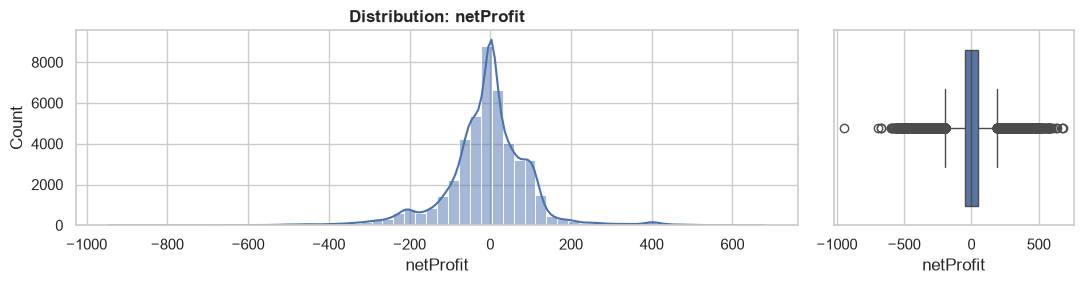

netProfit: n=46,520  mean=-6.69  median=-0.66  std=106.08  skew=-0.16


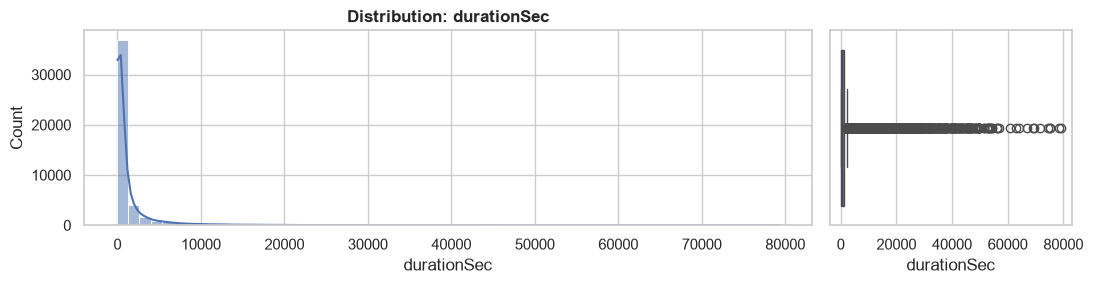

durationSec: n=46,520  mean=1415.87  median=272.00  std=3935.67  skew=7.08


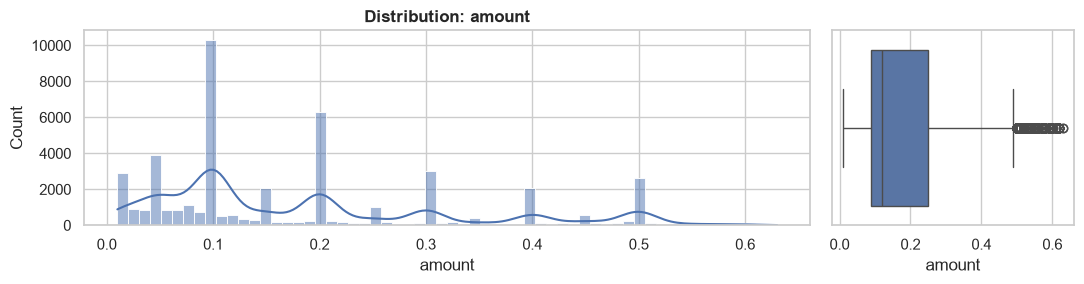

amount: n=46,520  mean=0.18  median=0.12  std=0.14  skew=1.02


In [13]:
# the three core numeric distributions — shape + outliers in one view each
for col in ["netProfit", "durationSec", "amount"]:
    plot_hist_box(df, col, title=f"Distribution: {col}")

**netProfit** — skew ≈ −0.16, close to symmetric. The single −944 loss is a genuine outlier, not representative of the overall shape; the median sits almost exactly at zero, so a "typical" trade is close to a wash and the real story is in the tails.

**durationSec** — skew ≈ 7, extreme. A small number of very long trades pull the mean (≈1,416s) far above the median (≈272s). Duration should always be reported and reasoned about via median/percentiles here, never the mean; trades beyond roughly the 75th percentile (≈995s) form a distinct "long-hold" cohort investigated further below.

**amount (lot size)** — not smooth: visibly spiky at round increments (0.1, 0.2, 0.3, 0.4, 0.5). Lot sizing is chosen in discrete steps rather than varied continuously — a genuine behavioural signal (rule-based or habitual sizing), not noise. Precise, non-round sizing could be a useful Stage 2 feature (may correlate with more rules-based/disciplined trading).

In [14]:
# 10 worst and 10 best trades by netProfit, side by side
extreme_cols = "accountId, campaignId, side, amount, durationSec, netProfit, slPrice, tpPrice"
extremes = con.execute(f"""
    (SELECT 'worst' AS tag, {extreme_cols} FROM trades ORDER BY netProfit ASC LIMIT 10)
    UNION ALL
    (SELECT 'best' AS tag, {extreme_cols} FROM trades ORDER BY netProfit DESC LIMIT 10)
""").fetchdf()
extremes.sort_values(["tag", "netProfit"])

,tag,accountId,campaignId,side,amount,durationSec,netProfit,slPrice,tpPrice
19,best,D#1702623,50,BUY,0.50,632,579.00,4698.84,4724.90
18,best,D#1702697,53,SELL,0.50,622,579.40,NaN,NaN
17,best,D#1702722,42,BUY,0.50,115,581.50,NaN,NaN
16,best,D#1702663,38,SELL,0.30,6224,588.60,NaN,NaN
15,best,D#1702598,62,SELL,0.30,2074,589.80,NaN,4080.23
14,best,D#1702524,56,BUY,0.10,41932,607.30,4492.31,4556.14
13,best,D#1702375,51,SELL,0.11,5985,626.44,4705.93,4646.06
12,best,D#1702506,62,SELL,0.50,199,636.50,NaN,NaN
11,best,D#1702439,58,SELL,0.55,14,672.09,NaN,NaN
10,best,D#1702718,35,SELL,0.48,99,680.64,NaN,NaN


Among the 10 worst trades, 9 of 10 had no stop-loss set (only one, at −577.80, had an SL); among the 10 best, 7 of 10 had none. No-SL is somewhat overrepresented on the loss side even at this small n, but it isn't a clean split — three of the best trades also had no SL, and duration doesn't separate the groups either (worst trades ran 178–11,975s; best trades ran 14–41,932s, including the single longest-held trade in the whole dataset). Eyeballing extremes alone doesn't settle the no-SL question — §5.4 tests it properly at scale.


In [15]:
# the 15 longest-held trades — what does the long tail from the boxplot above actually look like?
long_cols = "accountId, campaignId, side, amount, durationSec, netProfit, slPrice, tpPrice"
con.execute(f"SELECT {long_cols} FROM trades ORDER BY durationSec DESC LIMIT 15").fetchdf()

,accountId,campaignId,side,amount,durationSec,netProfit,slPrice,tpPrice
0,D#1702623,33,BUY,0.03,79210,-11.86,NaN,5491.36
1,D#1670955,55,BUY,0.01,78536,-17.59,NaN,NaN
2,D#1702502,65,SELL,0.02,75375,-48.96,NaN,3943.24
3,D#1702460,50,SELL,0.01,75111,12.67,NaN,NaN
4,D#1702379,33,BUY,0.01,74652,-21.50,NaN,NaN
5,D#1670951,38,BUY,0.03,71522,-109.30,NaN,NaN
6,D#1702441,40,SELL,0.02,69615,-207.56,4514.00,4158.00
7,D#1589419,33,BUY,0.01,69086,-20.11,NaN,NaN
8,D#1702577,33,SELL,0.03,66947,-30.22,NaN,NaN
9,D#1589450,45,BUY,0.01,63885,39.10,NaN,NaN


The 15 longest-held trades (15.6–22h) are dominated by losses — 12 of 15 have negative netProfit — and by absent stop-losses: 13 of 15 have no `slPrice` set. This is consistent with a "let it ride" pattern: positions held far past the ~272s median duration tend to be the ones a trader never protected with a stop and is reluctant to close at a loss, rather than a deliberate long-hold strategy (the 3 profitable long-holds don't share an obvious common trait).

> **Takeaway:** the working frame is well-behaved in scale (no negative/zero lots, one instrument) but has two fat tails worth carrying forward: a long-hold minority in `durationSec` that skews heavily toward no-SL losses, and a heavy loss/no-SL cluster in `netProfit`. Both are investigated further in §5.


## 3 · Data Quality

Always first, no exceptions — bad grain or silent nulls quietly wreck every conclusion downstream.

### 3.1 Duplicates

In [16]:
# full-row duplicates
con.execute("SELECT COUNT(*) AS n_distinct_rows FROM (SELECT DISTINCT * FROM trades)").fetchdf()

,n_distinct_rows
0,46520


In [17]:
# duplicates on the actual trade-identifying keys, not just full rows
con.execute("""
    SELECT COUNT(*) AS n_rows,
           COUNT(DISTINCT positionId) AS n_distinct_positionId,
           COUNT(DISTINCT closeTradeId) AS n_distinct_closeTradeId,
           COUNT(DISTINCT openOrderId) AS n_distinct_openOrderId
    FROM trades
""").fetchdf()

,n_rows,n_distinct_positionId,n_distinct_closeTradeId,n_distinct_openOrderId
0,46520,7277,10932,21292


In [18]:
# registry: is every account unique, and do any contact identifiers repeat across accounts?
# (repeated identifiers are a multi-accounting signal, explored further in §5.1)
con.execute("""
    SELECT
        COUNT(*) AS n_rows,
        COUNT(DISTINCT account) AS n_distinct_accounts,
        COUNT(*) - COUNT(DISTINCT email) AS n_email_repeats,
        COUNT(*) - COUNT(DISTINCT ip_address) AS n_ip_repeats
    FROM users
""").fetchdf()

,n_rows,n_distinct_accounts,n_email_repeats,n_ip_repeats
0,7000,500,2910,4631


No full-row duplicates (46,520 distinct rows out of 46,520). But the ID columns are a genuine surprise: only 7,277 distinct `positionId`, 10,932 distinct `closeTradeId`, and 21,292 distinct `openOrderId` values across 46,520 rows — none of them is a per-trade key, they repeat across many rows (including across different accounts, as seen in the zero-duration example above). Treated as validation/lineage fields only, never as a grain key (corrected in §2.1/§2.2).

The registry is far more duplicated: 7,000 rows for only 500 distinct accounts (14 rows/account, confirmed exactly in §4), with 2,910 repeated `email` values and 4,631 repeated `ip_address` values — consistent with the same 14-rows-per-account pattern rather than genuine cross-account identity sharing. Handled by deduplication in §4, not by deletion.

### 3.2 Missing values


In [19]:
# every trade column, not just the obvious SL/TP suspects
cols = con.execute("DESCRIBE trades").fetchdf()["column_name"].tolist()
null_checks = ", ".join(f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS {c}_nulls" for c in cols)
con.execute(f"SELECT {null_checks} FROM trades").fetchdf().T

,0
accountId_nulls,0.0
instrument_nulls,0.0
lotSize_nulls,0.0
closeTradeId_nulls,0.0
positionId_nulls,0.0
closeOrderId_nulls,0.0
openOrderId_nulls,0.0
durationSec_nulls,0.0
openDateTime_nulls,0.0
closeDateTime_nulls,0.0


Every column is complete except `slPrice` (24,601 nulls, ≈53%) and `tpPrice` (20,930 nulls, ≈45%). This is not missing data to clean away — it is a behavioural signal. Over half of all trades were placed with no stop-loss set at all, and just under half with no take-profit. That pattern is preserved as-is (never imputed) and formalized into `has_SL` / `has_TP` indicators in §4.

In [20]:
# registry completeness
con.execute("""
    SELECT
        SUM(CASE WHEN challenge_type_id IS NULL THEN 1 ELSE 0 END) AS challenge_type_id_nulls,
        SUM(CASE WHEN email IS NULL THEN 1 ELSE 0 END) AS email_nulls,
        SUM(CASE WHEN telegram_username IS NULL THEN 1 ELSE 0 END) AS telegram_nulls,
        SUM(CASE WHEN ip_address IS NULL THEN 1 ELSE 0 END) AS ip_nulls
    FROM users
""").fetchdf()

,challenge_type_id_nulls,email_nulls,telegram_nulls,ip_nulls
0,0.0,391.0,392.0,391.0


`challenge_type_id` is complete. `email` (391), `telegram_username` (392), and `ip_address` (391) each have a small number of nulls out of 7,000 rows (≈5.6%) — plausible incomplete sign-up data, not a structural issue, and irrelevant to `shared_ip_flag` beyond slightly undercounting shared clusters.

### 3.3 Data types

Timestamps arrive already timezone-aware (`TIMESTAMP WITH TIME ZONE`) from DuckDB. The one thing worth proving rather than assuming: that `durationSec` genuinely equals `closeDateTime − openDateTime`.


In [21]:
# reconcile durationSec against the timestamps it's supposed to summarize
computed_duration = (df["closeDateTime"] - df["openDateTime"]).dt.total_seconds()
duration_mismatch = (computed_duration - df["durationSec"]).abs()

print(f"Max |computed - stored| duration mismatch: {duration_mismatch.max():.2f} sec")
print(f"Rows with a mismatch > 1 sec: {(duration_mismatch > 1).sum()}")

Max |computed - stored| duration mismatch: 0.00 sec
Rows with a mismatch > 1 sec: 0


Perfect reconciliation: the maximum discrepancy between the stored `durationSec` and the timestamp-computed duration is 0.00 seconds across all 46,520 rows. `durationSec` can be trusted at face value.

### 3.4 Data validation

Formal rule checks with pass/fail counts, rather than trusting the ranges eyeballed in §2.3.


In [22]:
# rule checks with explicit pass/fail counts
tolerance = 0.01  # cents-level float tolerance

checks = {
    "closeDateTime >= openDateTime": df["closeDateTime"] >= df["openDateTime"],
    "amount > 0": df["amount"] > 0,
    "openPrice > 0 and closePrice > 0": (df["openPrice"] > 0) & (df["closePrice"] > 0),
    "netProfit == profit + commission + swap": (
        (df["profit"] + df["commission"] + df["swap"] - df["netProfit"]).abs() < tolerance
    ),
    "side in {BUY, SELL}": df["side"].isin(["BUY", "SELL"]),
}

validation_report = pd.DataFrame(
    {
        "rule": list(checks.keys()),
        "n_pass": [mask.sum() for mask in checks.values()],
        "n_fail": [(~mask).sum() for mask in checks.values()],
    }
).assign(pass_rate_pct=lambda d: (d["n_pass"] / len(df) * 100).round(2))

print(validation_report.to_string(index=False))

# reverseProfit is NOT exactly -profit (equality fails for every row at any sane tolerance) —
# checked separately as a correlation, matching how the relationship actually behaves.
reverse_corr = df["profit"].corr(df["reverseProfit"])
residual = df["reverseProfit"] + df["profit"]
print(f"\ncorr(profit, reverseProfit) = {reverse_corr:.5f}")
print(f"reverseProfit - (-profit): mean={residual.mean():.3f}, correlates with commission at r={residual.corr(df['commission']):.4f}")


                                   rule  n_pass  n_fail  pass_rate_pct
          closeDateTime >= openDateTime   46520       0          100.0
                             amount > 0   46520       0          100.0
       openPrice > 0 and closePrice > 0   46520       0          100.0
netProfit == profit + commission + swap   46520       0          100.0
                    side in {BUY, SELL}   46520       0          100.0

corr(profit, reverseProfit) = -0.99995
reverseProfit - (-profit): mean=-1.284, correlates with commission at r=0.9995


All five rules pass at 100% across all 46,520 rows: valid timestamp ordering, positive amounts and prices, `netProfit = profit + commission + swap` exactly, and `side` always `BUY`/`SELL`. The one relationship that is *not* exact equality — `reverseProfit` vs. `profit` — is checked separately above via correlation (r ≈ −0.9999): the two are near-perfectly anti-correlated but differ by a small residual that scales almost exactly with `commission` (a ~0.2×`commission` offset), which reads as C22 taking its own reduced commission on the mirrored position rather than a data-quality problem.

One edge case that passes every rule above but is still worth a look: trades with `durationSec = 0` (open and close in the same second). Not a validation failure — `closeDateTime >= openDateTime` holds — but a candidate for "instant fill" rather than a genuinely held position.


In [23]:
zero_duration = df[df["durationSec"] == 0]
print(f"{len(zero_duration)} zero-duration trades ({len(zero_duration) / len(df) * 100:.2f}% of all trades)")
zero_duration[["accountId", "campaignId", "side", "amount", "netProfit", "slPrice", "tpPrice"]]

13 zero-duration trades (0.03% of all trades)


,accountId,campaignId,side,amount,netProfit,slPrice,tpPrice
1023,D#1671050,34,SELL,0.05,-1.81,5344.08,NaN
3004,D#1671065,36,BUY,0.30,-10.20,NaN,NaN
3238,D#1702367,36,SELL,0.09,-2.62,5190.70,5183.44
4096,D#1702573,36,SELL,0.42,-40.74,5198.80,NaN
7537,D#1670924,39,BUY,0.24,4.32,NaN,NaN
15825,D#1671090,45,BUY,0.19,-13.69,NaN,NaN
22244,D#1702554,50,BUY,0.30,-7.80,NaN,NaN
35751,D#1702349,60,BUY,0.35,-8.06,NaN,NaN
37234,D#1702572,61,SELL,0.40,-26.80,NaN,NaN
37869,D#1670971,62,SELL,0.47,-15.99,NaN,NaN


Only 13 trades (0.03% of the dataset) — negligible in volume, and 12 of the 13 are losses, with only 2 carrying a stop-loss. Consistent with instant, likely accidental or immediately-regretted fills rather than a meaningful behavioural pattern on their own; too small an n to build a hypothesis on, but too clean a validation pass to need excluding either.

> **Takeaway:** the dataset is structurally clean — no full-row duplicates, no unexpected nulls outside SL/TP, and every validation rule is checked with an explicit pass/fail count rather than assumed. The one genuine structural surprise is that the trade "ID" columns (§3.1) and the registry (§3.1/§4) both have far more rows than genuine keys — addressed directly in §4, not silently worked around.


## 4 · Data Cleaning

Privacy is not optional here: the registry carries direct identifiers (`email`, `telegram_username`, `ip_address`), and this is a PDPA obligation, not a style choice. The rule followed below is **privacy first** — `email` and `telegram_username` are never loaded into any working dataframe, and `ip_address` is hashed into a group signal before it is dropped.

### 4.1 Cleaning steps performed

**Registry grain finding (from §3.1):** `users` has exactly 14 rows per account (7,000 rows / 500 accounts), with identical `challenge_type_id` but a different `email` / `telegram_username` / `ip_address` on every row — almost certainly a data-generation artifact (e.g. 14 stacked exports) rather than 14 genuine registrations. Deduplicating to one row per account is therefore a required cleaning step, not a stylistic choice: joining against the raw table would silently multiply every trade row ~14x. Because the surviving `ip_address` is picked arbitrarily among 14 candidates, the shared-IP signal built from it (§5.1) should be read as low-confidence, not a solid multi-accounting finding.

In [24]:
# --- Registry: PDPA-safe account table ---
# email / telegram_username are direct identifiers and are intentionally never selected.
# One row per account is taken deterministically (lowest ip_address) to fix the 14-rows-per-account
# duplication found in §3.1 — without this, joining trades to the raw registry would multiply every row.
accounts_clean = con.execute("""
    SELECT account, challenge_type_id, ip_address
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY account ORDER BY ip_address) AS rn
        FROM users
    )
    WHERE rn = 1
""").fetchdf()


def hash_identifier(value: str) -> str | None:
    """Deterministic short hash used only to group shared identifiers, not to recover them."""
    if pd.isna(value):
        return None
    return hashlib.sha256(str(value).encode()).hexdigest()[:12]


accounts_clean["shared_ip_group_id"] = accounts_clean["ip_address"].apply(hash_identifier)
accounts_clean["shared_ip_flag"] = accounts_clean.groupby("shared_ip_group_id")["account"].transform("nunique") > 1
accounts_clean = accounts_clean.drop(columns=["ip_address"])

accounts_clean.head()

,account,challenge_type_id,shared_ip_group_id,shared_ip_flag
0,D#1614602,11,0a9963e53cde,False
1,D#1670868,11,c618f5b6aab6,True
2,D#1670874,11,f4d2c2640038,True
3,D#1670982,11,4671164f3200,True
4,D#1702347,11,0da40ef01620,False


To resolve the 14-rows-per-account duplication (same `challenge_type_id`, different `ip_address` on each row), one row per account is kept deterministically — the row whose `ip_address` sorts first numerically — and the other 13 are discarded. That IP is then hashed, and `shared_ip_flag` is set to `True` when the hash collides with another account's chosen IP.

**Why this approach:** it resolves the 14-rows-per-account problem so joining trades to the registry doesn't multiply rows. The tradeoff is that discarding 13 of the 14 IPs per account risks undercounting genuine IP overlap.

In [60]:
# --- Trades: drop constant columns, standardize types, join population context ---
constant_cols = ["instrument", "lotSize", "swap", "currency", "openTradeCrossPrice", "closeTradeCrossPrice"]

trades_clean = df.drop(columns=constant_cols).copy()
trades_clean["side"] = trades_clean["side"].astype("category")
trades_clean["has_SL"] = trades_clean["slPrice"].notna()
trades_clean["has_TP"] = trades_clean["tpPrice"].notna()

trades_clean = trades_clean.merge(accounts_clean, left_on="accountId", right_on="account", how="left").drop(columns=["account"])

# make the cleaned frames queryable via SQL for the rest of the notebook
con.register("trades_clean", trades_clean)
con.register("accounts_clean", accounts_clean)

trades_clean.shape

(46520, 26)

`has_SL` / `has_TP` are boolean indicators used only for descriptive readability in the charts and tables below — they are not engineered model features (that is Stage 2 scope).

### 4.2 Validation after cleaning

Proving the cleaning preserved the data and removed the privacy risk, rather than assuming it did.

In [61]:
orig = con.execute("SELECT COUNT(*) AS n_rows, COUNT(DISTINCT accountId) AS n_accounts FROM trades").fetchdf().iloc[0]
no_raw_identifiers = not any(c in trades_clean.columns for c in ["email", "telegram_username", "ip_address"])

print("Row count preserved:    ", len(trades_clean) == orig["n_rows"], f"({len(trades_clean):,} vs {orig['n_rows']:,})")
print("Account count preserved:", trades_clean["accountId"].nunique() == orig["n_accounts"],
      f"({trades_clean['accountId'].nunique()} vs {orig['n_accounts']})")
print("Registry join is 1:1 (accounts_clean has one row per account):", accounts_clean["account"].is_unique)
print("No raw identifiers present:", no_raw_identifiers)
print("Columns dropped:", constant_cols)

Row count preserved:     True (46,520 vs 46,520)
Account count preserved: True (502 vs 502)
Registry join is 1:1 (accounts_clean has one row per account): True
No raw identifiers present: True
Columns dropped: ['instrument', 'lotSize', 'swap', 'currency', 'openTradeCrossPrice', 'closeTradeCrossPrice']


> **Takeaway:** `trades_clean` and `accounts_clean` are the analysis-ready, PII-free frames used for the rest of the notebook — same row/account counts as the raw table, six uninformative columns dropped, and every registry field capable of identifying a person removed or hashed before it ever left §4.

## 5 · EDA

### 5.1 Trader population

Who is in the sample — activity spread, groups, and multi-accounting — because this is the denominator for every behavioural claim that follows.

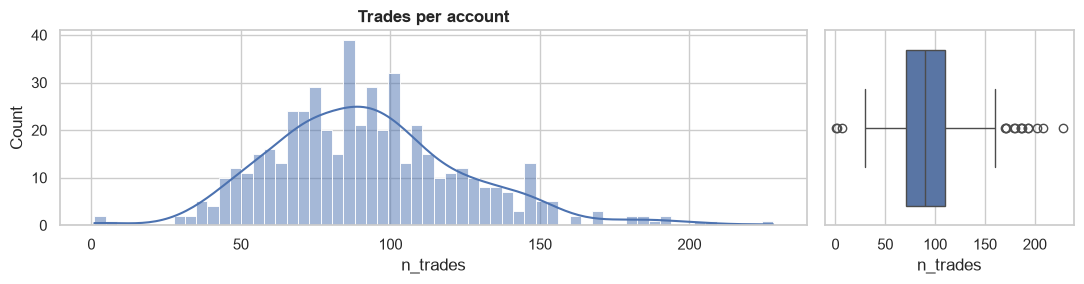

n_trades: n=502  mean=92.67  median=90.00  std=32.56  skew=0.64


In [27]:
# trades per account — how active is a typical trader?
trades_per_account = con.execute("""
    SELECT accountId, COUNT(*) AS n_trades
    FROM trades_clean GROUP BY accountId
""").fetchdf()

plot_hist_box(trades_per_account, "n_trades", title="Trades per account")

3. WHY is there a random spike at the 150 mark? 

In [28]:
#probing the spike
con.execute("""
    SELECT n_trades, COUNT(*) AS num_accounts
    FROM (SELECT accountId, COUNT(*) AS n_trades FROM trades_clean GROUP BY accountId)
    WHERE n_trades BETWEEN 140 AND 155
    GROUP BY n_trades
    ORDER BY n_trades
""").fetchdf()

,n_trades,num_accounts
0,140,4
1,141,2
2,142,1
3,145,7
4,146,2
5,147,1
6,148,3
7,149,2
8,150,1
9,151,1


seven accounts at the 145, higher than usual, why?

In [29]:
#probing why
con.execute("""
    SELECT accountId, COUNT(DISTINCT campaignId) AS num_campaigns, COUNT(*) AS n_trades
    FROM trades_clean
    WHERE accountId IN (
        SELECT accountId FROM trades_clean GROUP BY accountId HAVING COUNT(*) = 145
    )
    GROUP BY accountId
""").fetchdf()


,accountId,num_campaigns,n_trades
0,D#1702567,24,145
1,D#1614607,20,145
2,D#1702621,21,145
3,D#1670868,18,145
4,D#1702650,17,145
5,D#1589455,23,145
6,D#1645651,17,145


In [30]:
# userGroupId — is this cohort variable usable for group comparisons, or is it dominated by one value?
group_share = (
    trades_clean["userGroupId"].value_counts(normalize=True).mul(100).round(1).rename("pct_of_trades").reset_index()
)
group_share.columns = ["userGroupId", "pct_of_trades"]
group_share

,userGroupId,pct_of_trades
0,1583663,100.0
1,1583664,0.0
2,1583665,0.0


As extreme as the blueprint warned: `userGroupId` 1583663 accounts for 46,510 of 46,520 trades (99.98%); the other two values cover 9 and 1 trades respectively. Cross-group behavioural comparison is not feasible in this dataset — noted as a limitation, and a question for C22 on what this field is meant to encode.

**Population coverage over time.** If poorly-performing accounts quietly stop appearing in later campaigns, aggregate averages look artificially healthy — worth checking before trusting any campaign-level trend in §5.5.


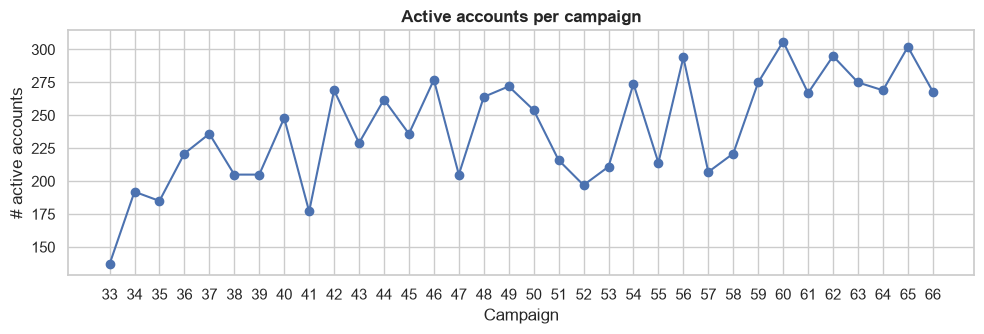

In [31]:
# active accounts per campaign, reusing the per-campaign counts computed in §2.1
plt.figure(figsize=(10, 3.5))
plt.plot(trades_per_campaign["campaignId"], trades_per_campaign["n_accounts"], marker="o", color="#4C72B0")
plt.title("Active accounts per campaign")
plt.xlabel("Campaign")
plt.ylabel("# active accounts")
plt.tight_layout()
plt.show()

Active accounts per campaign rise fairly steadily from 137 (campaign 33) to a peak of 306 (campaign 60), settling around 268–302 in the last few campaigns. This reads as programme growth (more traders joining over time) rather than survivorship bias — there's no sign of a collapse in participation that would make later-campaign averages artificially rosy.

**Shared-IP multi-accounting.** Accounts trading from the same hashed IP are a concrete integrity concern — either coordinated multi-accounting or, more benignly, shared infrastructure (café, VPN). Either way it's worth flagging, never silently dropping.


64 hashed IPs shared by more than one account, covering 190 accounts
Largest cluster: 9 accounts on one IP


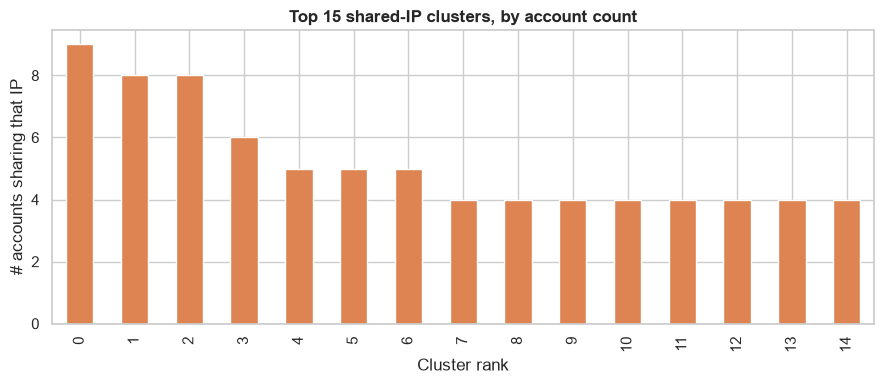

In [32]:
ip_group_sizes = accounts_clean[accounts_clean["shared_ip_flag"]].groupby("shared_ip_group_id")["account"].nunique().sort_values(ascending=False)

print(f"{len(ip_group_sizes)} hashed IPs shared by more than one account, covering {ip_group_sizes.sum()} accounts")
print(f"Largest cluster: {ip_group_sizes.max()} accounts on one IP")

plt.figure(figsize=(9, 4))
ip_group_sizes.head(15).reset_index(drop=True).plot(kind="bar", color="#DD8452")
plt.title("Top 15 shared-IP clusters, by account count")
plt.xlabel("Cluster rank")
plt.ylabel("# accounts sharing that IP")
plt.tight_layout()
plt.show()

In [33]:
# narrow that down to the population this notebook actually studies: the 502 accounts that traded XAUUSD
traded_flags = trades_clean.drop_duplicates("accountId")[["accountId", "shared_ip_flag"]]
n_traded_flagged = traded_flags["shared_ip_flag"].sum()
print(f"{n_traded_flagged} of {len(traded_flags)} traded accounts ({n_traded_flagged / len(traded_flags) * 100:.1f}%) sit on a shared IP")

189 of 502 traded accounts (37.6%) sit on a shared IP


64 hashed IPs are shared by more than one account, covering 190 of the 500 registered accounts; the largest cluster is 9 accounts on one IP. Narrowed to the traded population, 189 of 502 accounts (37.6%) sit on a shared IP — a large enough share to be a real integrity question, though per the §4 caveat, each account's `ip_address` was picked arbitrarily from 14 near-duplicate registry rows, so this specific rate should be read as directional, not precise.

> **Takeaway:** population size and activity spread are established here (§5.1), and will be reused as the denominator for every rate (no-SL %, win rate, etc.) computed in the rest of §5.


In [34]:
con.execute("""
    SELECT shared_ip_flag, 
           AVG(netProfit) AS avg_netprofit,
           AVG(CASE WHEN has_SL THEN 1 ELSE 0 END) AS pct_with_SL
    FROM trades_clean
    GROUP BY shared_ip_flag
""").fetchdf()


,shared_ip_flag,avg_netprofit,pct_with_SL
0,False,-6.858727,0.469317
1,True,-6.395091,0.474040
2,<NA>,-22.713000,0.800000


Flagged and unflagged accounts behave almost identically, so the shared-IP flag does not appear to affect trading behaviour — this hypothesis is not confounded by it.

### 5.2 Trading behaviour

How traders trade — direction, size, stop-loss discipline, and cadence. Distribution shapes for `amount`/`durationSec` were already established in §2.3; this section adds the categorical and per-account cuts.

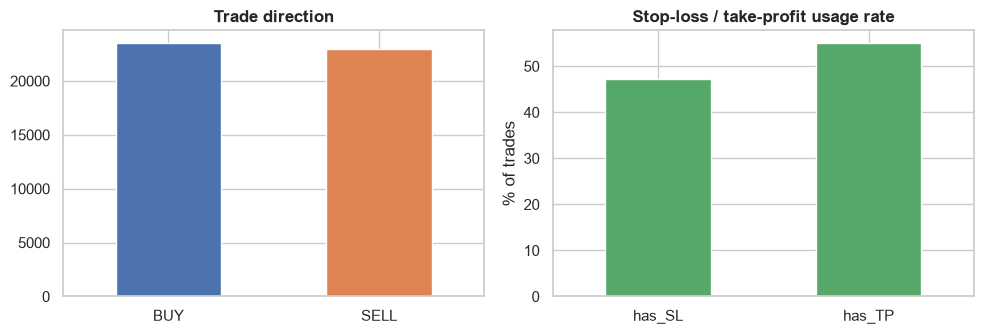

In [35]:
# direction bias and stop-loss / take-profit discipline, side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

trades_clean["side"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Trade direction")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

rate_df = pd.DataFrame(
    {"has_SL": [trades_clean["has_SL"].mean() * 100], "has_TP": [trades_clean["has_TP"].mean() * 100]}
).T.rename(columns={0: "pct_of_trades"})
rate_df.plot(kind="bar", ax=axes[1], color="#55A868", legend=False)
axes[1].set_title("Stop-loss / take-profit usage rate")
axes[1].set_ylabel("% of trades")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Direction is close to balanced — 23,509 BUY vs. 23,011 SELL (50.5% / 49.5%) — a much smaller long bias than the single-campaign blueprint sample suggested (62% BUY there). Stop-loss/take-profit usage confirms §3.2: only 47.1% of trades carry a stop-loss and 55.0% carry a take-profit.

Is the no-SL habit universal, or concentrated in a subset of traders? Accounts with at least 10 trades, ranked by their own no-SL rate:


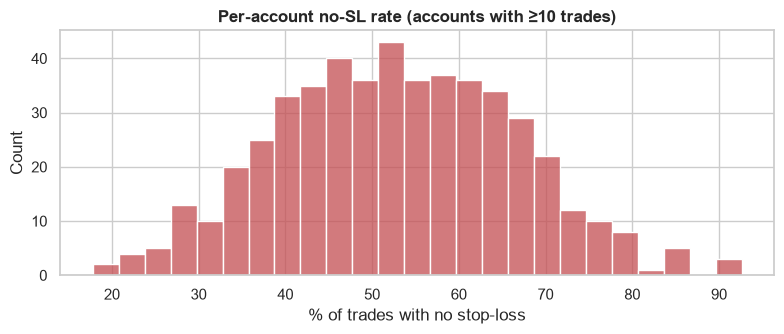

Accounts shown: 499. Fully no-SL (100%): 0. Fully disciplined (0%): 0.


In [36]:
no_sl_by_account = con.execute("""
    SELECT accountId,
           COUNT(*) AS n_trades,
           ROUND(100.0 * SUM(CASE WHEN NOT has_SL THEN 1 ELSE 0 END) / COUNT(*), 1) AS no_sl_pct
    FROM trades_clean
    GROUP BY accountId
    HAVING COUNT(*) >= 10
    ORDER BY no_sl_pct DESC
""").fetchdf()

plt.figure(figsize=(8, 3.5))
sns.histplot(no_sl_by_account["no_sl_pct"], bins=25, color="#C44E52")
plt.title("Per-account no-SL rate (accounts with ≥10 trades)")
plt.xlabel("% of trades with no stop-loss")
plt.tight_layout()
plt.show()
print(f"Accounts shown: {len(no_sl_by_account)}. Fully no-SL (100%): {(no_sl_by_account['no_sl_pct'] == 100).sum()}. Fully disciplined (0%): {(no_sl_by_account['no_sl_pct'] == 0).sum()}.")

Among the 499 accounts with ≥10 trades, not one is fully consistent in either direction — nobody has a 0% or 100% no-SL rate. The habit is a spread across the population rather than a clean "disciplined vs. undisciplined" split, which argues against treating no-SL usage as a fixed trait and for treating it as a per-trade, situational choice.

Lot-size discipline for the 15 most active accounts — is sizing consistent per trader, or erratic?


This matters a lot for how you frame your memo. Instead of "traders who skip SL underperform" (implying two clean groups), the better-supported hypothesis is: "no-SL usage is a graded behavior — does a trader's no-SL rate correlate with their overall performance, rather than whether they ever skip it?"

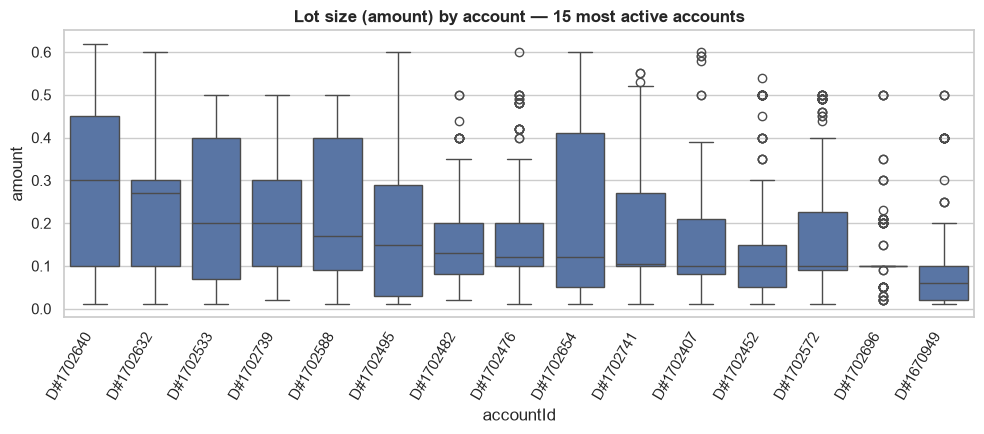

In [37]:
top_accounts = trades_per_account.nlargest(15, "n_trades")["accountId"]
top_trades = trades_clean[trades_clean["accountId"].isin(top_accounts)]

plt.figure(figsize=(10, 4.5))
order = top_trades.groupby("accountId")["amount"].median().sort_values(ascending=False).index
sns.boxplot(data=top_trades, x="accountId", y="amount", order=order, color="#4C72B0")
plt.title("Lot size (amount) by account — 15 most active accounts")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Median lot size across these 15 accounts ranges from 0.06 to 0.30 — a genuine 5x spread in typical position size between traders. Within each account the spread is wide too: nearly every one of the 15 has traded lots spanning most of the 0.01–0.63 range, so "consistent per-trader sizing" doesn't hold even for the most active accounts — sizing looks reactive/situational rather than fixed.

**Cadence.** How quickly does a trader move from closing one position to opening the next? Short gaps suggest reactive re-entry; this also sets up the after-loss vs. after-win comparison in §5.3.


traders pick from a mental shortlist of round sizes, but which size they pick each time is situational, not fixed

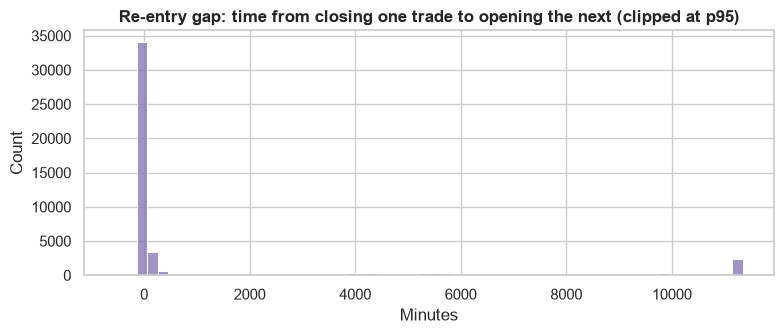

reentry_gap_min (unclipped): n=46,018  mean=1813.55  median=4.37  std=5219.90  skew=4.32


In [38]:
# per-account trade sequence, sorted by time — the base frame reused again in §5.3
trades_sorted = trades_clean.sort_values(["accountId", "openDateTime"]).copy()
trades_sorted["prev_close"] = trades_sorted.groupby("accountId", observed=True)["closeDateTime"].shift(1)
trades_sorted["reentry_gap_min"] = (trades_sorted["openDateTime"] - trades_sorted["prev_close"]).dt.total_seconds() / 60

gap = trades_sorted["reentry_gap_min"].dropna()
gap_clipped = gap.clip(upper=gap.quantile(0.95))  # clip the long tail (across-day gaps) purely for readability

plt.figure(figsize=(8, 3.5))
sns.histplot(gap_clipped, bins=60, color="#8172B2")
plt.title("Re-entry gap: time from closing one trade to opening the next (clipped at p95)")
plt.xlabel("Minutes")
plt.tight_layout()
plt.show()
describe_distribution(gap, "reentry_gap_min (unclipped)")

Median re-entry gap is just 4.4 minutes — most traders move from one trade straight into the next. The mean (≈30 hours) is dragged far above that by a long tail of gaps spanning across sessions/campaigns, another case where the median is the number to reason with, not the mean. Fast re-entry as the norm is exactly the setup §5.3 needs to ask whether that re-entry speeds up or slows down specifically after a loss.

> **Takeaway:** direction, sizing, stop-loss usage, and cadence are the raw behavioural texture; §5.3 asks whether any of it shifts once a trader is under pressure.


Possible hypothesis: most traders jump straight into the next trade right after closing one. Does that re-entry speed change specifically after a loss vs. a win?

### 5.3 Behaviour under pressure

Does behaviour change as losses mount or right after a losing trade? This is the closest this notebook gets to the actual challenge mechanics, and exactly where C22's reverse position profits.

**Caveat carried from §1.2:** starting account balance is not in this dataset, so drawdown below is expressed in absolute USD / relative to each account's own peak `netProfit` — never as a literal % against the 4% rule threshold.

**Sample equity curves** (cumulative `netProfit`, a proxy for account equity) for six moderately active accounts:

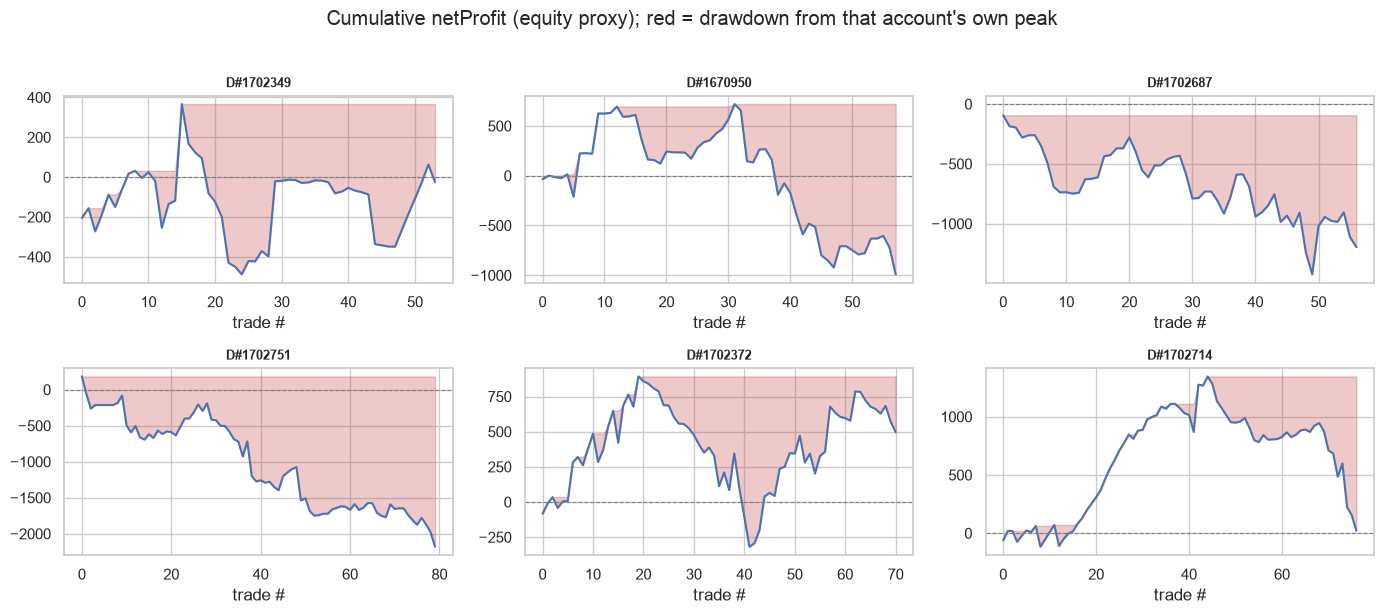

In [39]:
# six moderately active accounts (40-80 trades), fixed seed for reproducibility
moderately_active = trades_per_account[trades_per_account["n_trades"].between(40, 80)]
sample_accounts = moderately_active["accountId"].sample(6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, acc in zip(axes.flat, sample_accounts):
    sub = trades_sorted[trades_sorted["accountId"] == acc]
    equity = sub["netProfit"].cumsum().values
    running_max = pd.Series(equity).cummax().values
    x = range(len(equity))
    ax.plot(x, equity, color="#4C72B0", linewidth=1.5)
    ax.fill_between(x, equity, running_max, color="#C44E52", alpha=0.3)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(acc, fontsize=9)
    ax.set_xlabel("trade #")
fig.suptitle("Cumulative netProfit (equity proxy); red = drawdown from that account's own peak", y=1.02)
plt.tight_layout()
plt.show()

Four of the six sampled accounts finish net negative, one grinds to roughly breakeven, one finishes clearly positive — directionally in line with the population's loser-heavy split (§5.4). The losing accounts show substantial drawdown from their own peak (in the hundreds to low thousands of USD) with only partial recovery, rather than one catastrophic trade — consistent with the "long-hold, no-SL, let it ride" pattern already flagged in §2.3/§3.4.

**After a loss vs. after a win.** For every trade, does the *previous* trade on that same account end in profit or loss — and does that change position size or how quickly the trader re-enters?


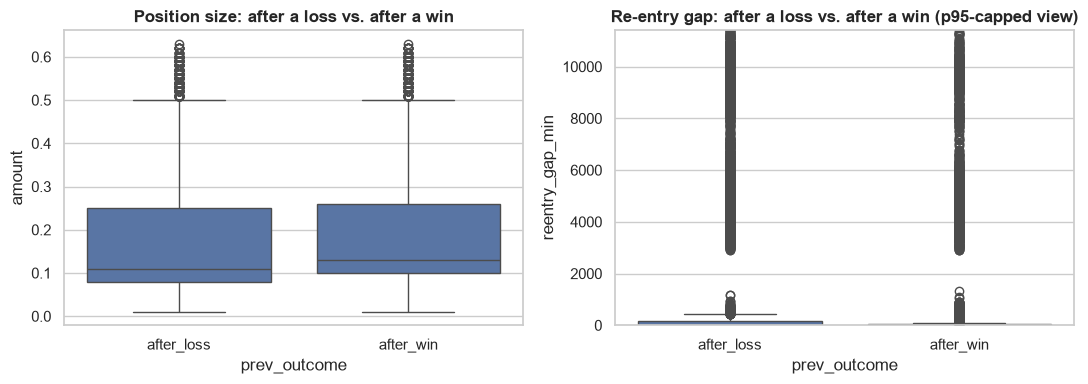

,amount,reentry_gap_min
prev_outcome,,
after_loss,0.11,3.5
after_win,0.13,5.1


In [40]:
def classify_prior_outcome(prev_profit):
    if pd.isna(prev_profit):
        return None
    if prev_profit > 0:
        return "after_win"
    if prev_profit < 0:
        return "after_loss"
    return "after_breakeven"


trades_sorted["prev_netProfit"] = trades_sorted.groupby("accountId", observed=True)["netProfit"].shift(1)
trades_sorted["prev_outcome"] = trades_sorted["prev_netProfit"].apply(classify_prior_outcome)

pressure_df = trades_sorted[trades_sorted["prev_outcome"].isin(["after_loss", "after_win"])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=pressure_df, x="prev_outcome", y="amount", order=["after_loss", "after_win"], ax=axes[0])
axes[0].set_title("Position size: after a loss vs. after a win")

gap_cap = pressure_df["reentry_gap_min"].quantile(0.95)
sns.boxplot(data=pressure_df, x="prev_outcome", y="reentry_gap_min", order=["after_loss", "after_win"], ax=axes[1])
axes[1].set_ylim(0, gap_cap)
axes[1].set_title("Re-entry gap: after a loss vs. after a win (p95-capped view)")

plt.tight_layout()
plt.show()

pressure_df.groupby("prev_outcome", observed=True)[["amount", "reentry_gap_min"]].median()

At the trade level, median position size is actually *smaller* after a loss than after a win (0.11 vs. 0.13 lots) — the opposite of simple loss-chasing-by-size. Re-entry is faster after a loss, though (median 3.5 minutes vs. 5.1 minutes after a win). So there's no evidence of sizing up after a loss here, but there is a hint of speeding up — worth distinguishing "chasing via size" from "chasing via haste." Note: this is a trade-level, exploratory cut — trades within an account aren't independent, so §5.5 re-tests the sizing question with a per-account paired test.

**Hours into the session.** Treating each account's first trade in a given campaign as that challenge attempt's start, does behaviour drift over the ~1-day window?


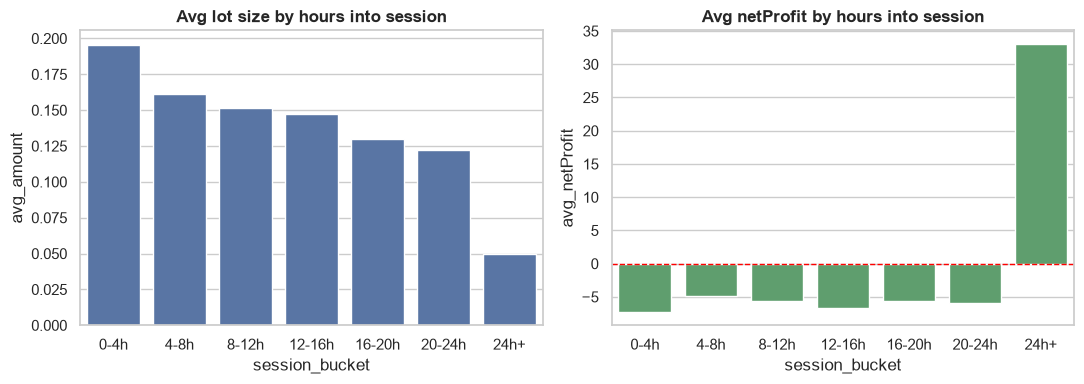

,session_bucket,avg_amount,avg_netProfit,n_trades
0,0-4h,0.195763,-7.255023,32668
1,4-8h,0.161432,-4.858231,7446
2,8-12h,0.151525,-5.671406,4282
3,12-16h,0.147082,-6.698296,1655
4,16-20h,0.130109,-5.558989,366
5,20-24h,0.122100,-5.859900,100
6,24h+,0.050000,33.066667,3


In [41]:
session_start = trades_clean.groupby(["accountId", "campaignId"])["openDateTime"].transform("min")
hours_into_session = (trades_clean["openDateTime"] - session_start).dt.total_seconds() / 3600

bins = [0, 4, 8, 12, 16, 20, 24, hours_into_session.max() + 1]
labels = ["0-4h", "4-8h", "8-12h", "12-16h", "16-20h", "20-24h", "24h+"]
session_bucket = pd.cut(hours_into_session, bins=bins, labels=labels, include_lowest=True)

bucket_stats = (
    trades_clean.assign(session_bucket=session_bucket)
    .groupby("session_bucket", observed=True)
    .agg(avg_amount=("amount", "mean"), avg_netProfit=("netProfit", "mean"), n_trades=("netProfit", "size"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=bucket_stats, x="session_bucket", y="avg_amount", ax=axes[0], color="#4C72B0")
axes[0].set_title("Avg lot size by hours into session")
sns.barplot(data=bucket_stats, x="session_bucket", y="avg_netProfit", ax=axes[1], color="#55A868")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Avg netProfit by hours into session")
plt.tight_layout()
plt.show()

bucket_stats

Two clear patterns. First, activity is heavily front-loaded: 32,668 of ~46,500 trades (≈70%) happen in the first 4 hours of a session, falling off sharply after that. Second, average lot size steadily shrinks the longer a session runs — from 0.196 in the first 4 hours down to 0.12 by hour 20–24 — the opposite of size escalating under time pressure. Average netProfit per trade is consistently negative and fairly flat across the meaningful buckets (−4.9 to −7.3); the apparent +33 average in the "24h+" bucket is not a real signal — it's 3 trades.

> **Takeaway:** §5.3 is the descriptive core of the pressure story — equity curves, after-loss reaction, and time-in-session are all assembled here strictly as observation, with no feature engineering. None of the three cuts here show traders escalating size or risk under pressure; if anything sizing shrinks. §5.4 now asks whether any of this behaviour actually separates winners from losers.


### 5.4 Successful vs. unsuccessful traders

The most direct hypothesis-seeding cut: contrast winners and losers to see what actually separates them.

**Outcome proxy:** sum of `netProfit` per account, sign only (`winner` if positive). This is **not** the true challenge pass/fail outcome — that needs the starting balance and a breach label, neither of which is in this dataset (§1.2). Treat it as a P&L proxy throughout this section.

In [42]:
# one row per account — the grain used for the rest of §5.4/§5.5 and for §7
account_summary = con.execute("""
    SELECT
        accountId,
        COUNT(*) AS n_trades,
        SUM(netProfit) AS total_netProfit,
        AVG(netProfit) AS avg_netProfit,
        STDDEV(netProfit) AS profit_volatility,
        AVG(amount) AS avg_amount,
        MEDIAN(durationSec) AS median_durationSec,
        SUM(commission) AS total_commission,
        100.0 * SUM(CASE WHEN NOT has_SL THEN 1 ELSE 0 END) / COUNT(*) AS no_sl_pct,
        100.0 * SUM(CASE WHEN NOT has_TP THEN 1 ELSE 0 END) / COUNT(*) AS no_tp_pct
    FROM trades_clean
    GROUP BY accountId
""").fetchdf()
account_summary["outcome"] = account_summary["total_netProfit"].apply(lambda x: "winner" if x > 0 else "loser")

account_summary.to_csv("../Data/processed/account_summary.csv", index=False)
account_summary.describe()

,n_trades,total_netProfit,avg_netProfit,profit_volatility,avg_amount,median_durationSec,total_commission,no_sl_pct,no_tp_pct
count,502.000000,502.000000,502.000000,501.000000,502.000000,502.000000,502.000000,502.000000,502.000000
mean,92.669323,-619.668327,-7.974741,107.996294,0.183291,366.546813,-596.094761,52.664009,44.365641
std,32.559269,985.013939,14.530160,20.791136,0.043726,641.946992,255.490125,14.196966,14.050303
min,1.000000,-3450.210000,-150.600000,60.914485,0.038571,37.000000,-1744.860000,0.000000,0.000000
25%,71.000000,-1281.195000,-15.753606,95.294562,0.153743,207.625000,-732.397500,42.604850,34.365509
50%,90.000000,-680.010000,-7.571619,105.330595,0.180982,282.250000,-569.300000,52.798434,44.264507
75%,110.000000,66.637500,0.584003,119.479317,0.210877,407.875000,-414.945000,62.626263,53.008021
max,228.000000,2076.920000,34.047869,280.035499,0.430000,12404.000000,-3.500000,100.000000,89.108911


134 winners vs. 368 losers (27% / 73%) by the netProfit-sign proxy — most accounts in this sample lose money overall, consistent with C22's business model in §1.1. `total_commission` averages −596 per account against an average `total_netProfit` of −620, so commission alone accounts for a large share of the typical account's loss before directional trading is even considered (developed further in §5.5).

Do behavioural metrics actually differ between the two groups? Mann-Whitney U (non-parametric, appropriate given the modest per-group n and skewed metrics) on each behaviour, comparing winners vs. losers:


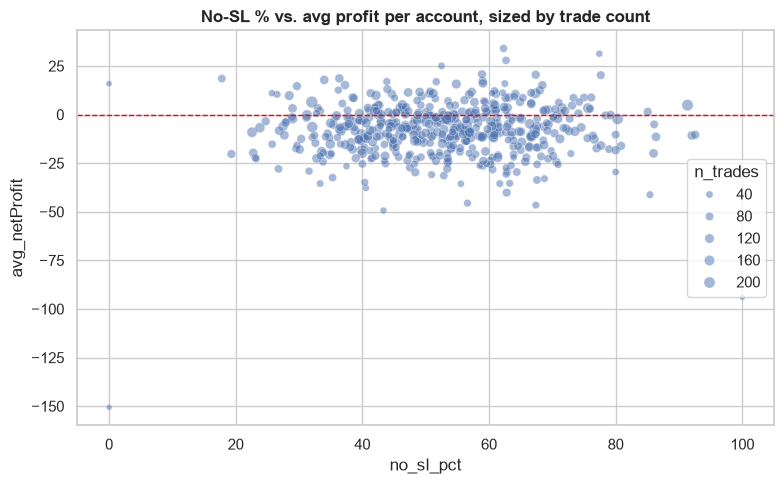

In [43]:
# is there a visible split, or a continuum? — visual segmentation before any formal test
plt.figure(figsize=(8, 5))
sns.scatterplot(data=account_summary, x="no_sl_pct", y="avg_netProfit", size="n_trades", alpha=0.5, legend="brief")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("No-SL % vs. avg profit per account, sized by trade count")
plt.tight_layout()
plt.show()

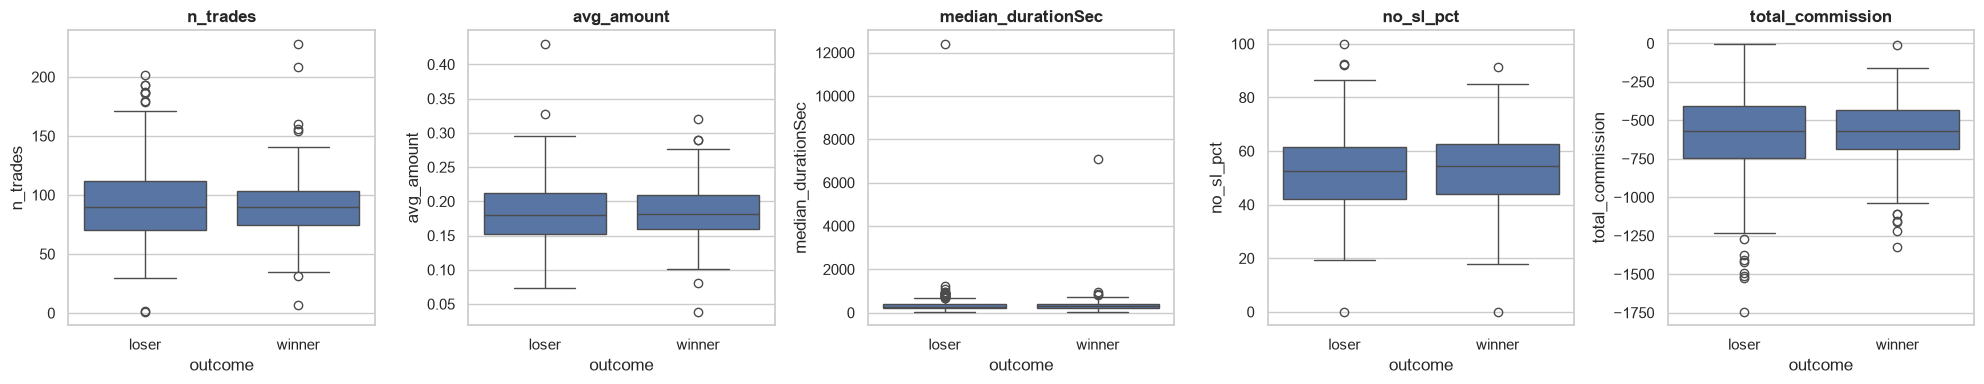

,metric,winner_median,loser_median,p_value
0,n_trades,90.0000,89.5000,0.7742
1,avg_amount,0.1819,0.1802,0.5368
2,median_durationSec,295.2500,281.0000,0.5590
3,no_sl_pct,54.5072,52.6316,0.2194
4,total_commission,-566.5700,-570.1500,0.9175


In [44]:
behaviour_metrics = ["n_trades", "avg_amount", "median_durationSec", "no_sl_pct", "total_commission"]
winners = account_summary[account_summary["outcome"] == "winner"]
losers = account_summary[account_summary["outcome"] == "loser"]

fig, axes = plt.subplots(1, len(behaviour_metrics), figsize=(4 * len(behaviour_metrics), 4))
test_rows = []
for ax, metric in zip(axes, behaviour_metrics):
    sns.boxplot(data=account_summary, x="outcome", y=metric, order=["loser", "winner"], ax=ax)
    ax.set_title(metric)
    u_stat, p_value = stats.mannwhitneyu(winners[metric], losers[metric], alternative="two-sided")
    test_rows.append({"metric": metric, "winner_median": winners[metric].median(), "loser_median": losers[metric].median(), "p_value": p_value})
plt.tight_layout()
plt.show()

pd.DataFrame(test_rows).round(4)

at the account level, none of the behaviours actually seperate winners from losers

None of the five behaviours reach significance (all p > 0.2, most > 0.5): trade count, average lot size, median duration, no-SL rate, and total commission are all statistically indistinguishable between winners and losers at the account level. This is a genuine null result, not a weak positive — none of these simple, individually-measured behaviours separates the two groups on their own. It doesn't rule out combinations of behaviours or the pressure-response patterns from §5.3, only that no single one of these five does the job alone.

Two complementary cuts on the stop-loss question specifically — first at the trade level, then re-testing the same idea by splitting accounts at a 50% no-SL threshold (independent of the winner/loser split above):


In [45]:
# trade-level: does having a stop-loss set correlate with the outcome of that specific trade?
con.execute("""
    SELECT
        CASE WHEN has_SL THEN 'Has SL' ELSE 'No SL' END AS sl_status,
        COUNT(*) AS n_trades,
        AVG(netProfit) AS avg_profit,
        MEDIAN(netProfit) AS median_profit,
        MIN(netProfit) AS worst_loss
    FROM trades_clean
    GROUP BY sl_status
""").fetchdf()

,sl_status,n_trades,avg_profit,median_profit,worst_loss
0,No SL,24601,-10.008681,1.98,-944.1
1,Has SL,21919,-2.958618,-10.56,-577.8


In [46]:
# account-level: split accounts at a 50% no-SL threshold, compare average profit
high_no_sl = account_summary.loc[account_summary["no_sl_pct"] >= 50, "avg_netProfit"]
low_no_sl = account_summary.loc[account_summary["no_sl_pct"] < 50, "avg_netProfit"]

t_stat, p_value = stats.ttest_ind(high_no_sl, low_no_sl, equal_var=False)
print(f"High no-SL (>=50%) avg profit: {high_no_sl.mean():.2f}  (n={len(high_no_sl)})")
print(f"Low no-SL (<50%) avg profit:  {low_no_sl.mean():.2f}  (n={len(low_no_sl)})")
print(f"Welch t-stat: {t_stat:.3f}, p-value: {p_value:.4f}")

High no-SL (>=50%) avg profit: -7.57  (n=289)
Low no-SL (<50%) avg profit:  -8.52  (n=213)
Welch t-stat: 0.715, p-value: 0.4748


A more nuanced picture than "no-SL is simply worse." At the trade level, no-SL trades have a *worse average* (−10.01 vs. −2.96) and a *worse worst-case* (−944.10 vs. −577.80) than trades with a stop-loss — but a *better median* (+1.98 vs. −10.56). That combination — better typical outcome, worse average and worse tail — is the signature of a fat-tailed risk profile: no-SL trades more often drift to a small profit but occasionally run into a catastrophic loss that drags the mean down. This is consistent with "not setting a stop" being a bet that mostly pays off in small amounts but occasionally blows up, rather than a uniformly bad habit.

At the account level, splitting at a 50% no-SL threshold shows no significant difference either (high no-SL accounts average −7.57 vs. −8.52 for low no-SL, p = 0.47) — if anything the high-no-SL group is *slightly* better, though not distinguishably so. Both the trade-level asymmetry and the account-level null result point the same way: no-SL usage is not a simple, linearly "worse" behaviour in this data — its cost shows up in tail risk, not typical outcome.




In [47]:
#Re-entry gap, split by after-loss vs. after-win, rolled up per account

# first, get prev_outcome and gap at the trade level (same logic as before)
trades_sorted = con.execute("SELECT * FROM trades_clean ORDER BY accountId, openDateTime").fetchdf()

trades_sorted["prev_netProfit"] = trades_sorted.groupby("accountId")["netProfit"].shift(1)
trades_sorted["prev_outcome"] = trades_sorted["prev_netProfit"].apply(
    lambda x: "after_loss" if x < 0 else ("after_win" if x >= 0 else None)
)
trades_sorted["prev_closeDateTime"] = trades_sorted.groupby("accountId")["closeDateTime"].shift(1)
trades_sorted["reentry_gap_min"] = (
    trades_sorted["openDateTime"] - trades_sorted["prev_closeDateTime"]
).dt.total_seconds() / 60

# now roll up to one row per account: avg gap after loss vs after win
reentry_by_account = trades_sorted.groupby(["accountId", "prev_outcome"])["reentry_gap_min"].median().unstack()
reentry_by_account.columns = ["avg_reentry_after_loss", "avg_reentry_after_win"]
reentry_by_account = reentry_by_account.reset_index()


#Direction bias (% BUY) per account
buy_pct = con.execute("""
    SELECT accountId, 
           100.0 * SUM(CASE WHEN side = 'BUY' THEN 1 ELSE 0 END) / COUNT(*) AS pct_buy
    FROM trades_clean
    GROUP BY accountId
""").fetchdf()

#Long-hold cohort — % of trades past the 75th percentile duration

long_hold_pct = con.execute("""
    SELECT accountId,
           100.0 * SUM(CASE WHEN durationSec > 995 THEN 1 ELSE 0 END) / COUNT(*) AS long_hold_pct
    FROM trades_clean
    GROUP BY accountId
""").fetchdf()

#Max drawdown per account

def compute_max_drawdown(group):
    equity = group.sort_values("openDateTime")["netProfit"].cumsum()
    running_max = equity.cummax()
    drawdown = equity - running_max
    return drawdown.min()  # most negative point = deepest drawdown

max_dd = trades_sorted.groupby("accountId").apply(compute_max_drawdown).reset_index()
max_dd.columns = ["accountId", "max_drawdown"]


#Merge everything into account_summary

account_summary_full = (
    account_summary
    .merge(reentry_by_account, on="accountId", how="left")
    .merge(buy_pct, on="accountId", how="left")
    .merge(long_hold_pct, on="accountId", how="left")
    .merge(max_dd, on="accountId", how="left")
)

account_summary_full.head()



,accountId,n_trades,total_netProfit,avg_netProfit,profit_volatility,avg_amount,median_durationSec,total_commission,no_sl_pct,no_tp_pct,outcome,avg_reentry_after_loss,avg_reentry_after_win,pct_buy,long_hold_pct,max_drawdown
0,D#1702718,100,-1728.71,-17.287100,123.419858,0.178800,303.0,-625.98,77.000000,44.000000,loser,7.541667,7.200000,43.000000,28.000000,-2389.34
1,D#1671094,100,-2616.60,-26.166000,113.972852,0.184000,184.0,-644.42,59.000000,59.000000,loser,0.916667,2.633333,51.000000,16.000000,-3147.49
2,D#1702495,171,-857.99,-5.017485,96.211192,0.162047,447.0,-970.36,54.970760,50.877193,loser,2.233333,3.575000,53.801170,31.578947,-1919.61
3,D#1670950,58,-991.25,-17.090517,155.062430,0.143103,767.0,-290.68,44.827586,41.379310,loser,8.733333,14.800000,56.896552,39.655172,-1711.26
4,D#1702412,71,-964.22,-13.580563,124.560011,0.159859,447.0,-397.50,56.338028,33.802817,loser,16.908333,25.058333,76.056338,33.802817,-1390.25


In [48]:
behaviour_metrics = ["n_trades", "avg_amount", "median_durationSec", "no_sl_pct", 
                     "total_commission", "avg_reentry_after_loss", "avg_reentry_after_win",
                     "pct_buy", "long_hold_pct", "max_drawdown"]

winners = account_summary_full[account_summary_full["outcome"] == "winner"]
losers = account_summary_full[account_summary_full["outcome"] == "loser"]

test_rows = []
for metric in behaviour_metrics:
    # drop NaNs for this specific metric (some accounts won't have an after_loss or after_win gap if they never lost/won)
    w = winners[metric].dropna()
    l = losers[metric].dropna()
    u_stat, p_value = stats.mannwhitneyu(w, l, alternative="two-sided")
    test_rows.append({
        "metric": metric,
        "winner_median": w.median(),
        "loser_median": l.median(),
        "p_value": round(p_value, 4)
    })

pd.DataFrame(test_rows)

,metric,winner_median,loser_median,p_value
0,n_trades,90.000000,89.500000,0.7742
1,avg_amount,0.181918,0.180156,0.5368
2,median_durationSec,295.250000,281.000000,0.5590
3,no_sl_pct,54.507246,52.631579,0.2194
4,total_commission,-566.570000,-570.150000,0.9175
5,avg_reentry_after_loss,3.800000,4.179167,0.1854
6,avg_reentry_after_win,6.470833,5.383333,0.0291
7,pct_buy,51.714286,50.676788,0.2968
8,long_hold_pct,27.071078,25.105042,0.0975
9,max_drawdown,-839.265000,-1515.030000,0.0000


key findings : 
1. losing accounts, on average, fell much further from their own peak (-1515) than winning accounts did (-839), before things were said and done. In plain terms: the losers didn't necessarily trade "worse" on every single metric — they let things fall further before turning it around (or not turning it around at all)
2. winners may be a little more patient/deliberate after a win, rather than immediately re-entering. (losers enter faster)


Across ten behavioral metrics tested against outcome, only maximum drawdown from an account's own peak showed a strong, statistically significant relationship (p < 0.001) — losing accounts drew down roughly 80% deeper than winning accounts before any recovery. This suggests that how much an account lets its equity fall before cutting losses or recovering is the behavioral factor most associated with poor outcomes in this dataset.


Best- and worst-performing accounts by average profit, for concrete grounding rather than only aggregate statistics:

In [49]:
display_cols = ["accountId", "n_trades", "avg_netProfit", "total_netProfit", "no_sl_pct", "outcome"]
print("Worst 5 accounts by avg profit:")
display(account_summary.sort_values("avg_netProfit").head(5)[display_cols])
print("\nBest 5 accounts by avg profit:")
display(account_summary.sort_values("avg_netProfit", ascending=False).head(5)[display_cols])

Worst 5 accounts by avg profit:


,accountId,n_trades,avg_netProfit,total_netProfit,no_sl_pct,outcome
296,D#1759507,1,-150.600000,-150.60,0.000000,loser
394,D#1645639,2,-93.965000,-187.93,100.000000,loser
352,D#1702384,30,-49.361333,-1480.84,43.333333,loser
158,D#1702360,46,-46.553696,-2141.47,67.391304,loser
383,D#1702672,53,-45.556226,-2414.48,56.603774,loser



Best 5 accounts by avg profit:


,accountId,n_trades,avg_netProfit,total_netProfit,no_sl_pct,outcome
409,D#1702409,61,34.047869,2076.92,62.295082,winner
485,D#1702712,31,31.344839,971.69,77.419355,winner
495,D#1614609,67,27.901343,1869.39,62.686567,winner
76,D#1702704,40,25.068750,1002.75,52.500000,winner
355,D#1702516,90,20.739778,1866.58,58.888889,winner


> **Takeaway:** §5.4 tests which behaviours actually separate the P&L-proxy winners from losers, rather than assuming any of §5.2/§5.3's behaviours matter. §5.5 broadens the search to patterns that aren't framed around winner/loser at all.

winner - ended up net +ve and losers with net -ve

### 5.5 Pattern discovery

Open-ended search for repeatable structures not covered above — the surface most of the memo's original observations should come from.

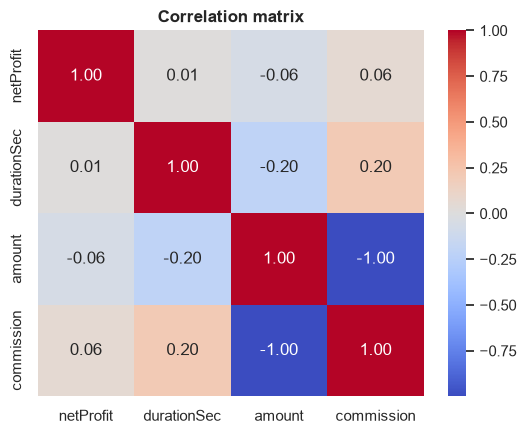

In [50]:
# correlation across the core numeric fields — used sparingly, just to catch obvious linear links
corr_cols = ["netProfit", "durationSec", "amount", "commission"]
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(trades_clean[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

this is an expected finding - amount and commision are inversely correlated

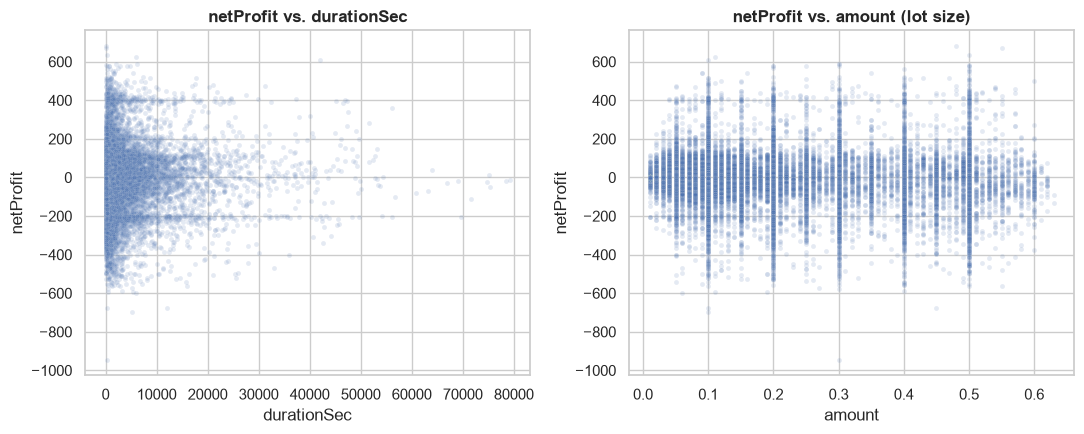

In [51]:
# shape of the relationships a correlation coefficient alone can't show
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.scatterplot(data=trades_clean, x="durationSec", y="netProfit", alpha=0.15, s=12, ax=axes[0])
axes[0].set_title("netProfit vs. durationSec")
sns.scatterplot(data=trades_clean, x="amount", y="netProfit", alpha=0.15, s=12, ax=axes[1])
axes[1].set_title("netProfit vs. amount (lot size)")
plt.tight_layout()
plt.show()

`amount` and `commission` correlate at exactly −1.00 — commission is a deterministic, fixed rate per lot, not an independent cost. Everything else is weak: `netProfit` has essentially no linear relationship with duration, size, or commission individually (|r| ≤ 0.06), and `durationSec` vs. `amount` is only mildly negative (−0.20, larger positions held slightly less long). The scatterplots confirm there's no obvious nonlinear shape either — both clouds are diffuse with no visible curve or threshold effect. Profit isn't explained by any single trade characteristic in isolation; the account-level and pressure-response cuts elsewhere in §5 are doing the real work.

**Friction.** How does total commission collected compare to traders' aggregate directional (gross) loss? If commission alone exceeds the directional loss, cost is doing more damage than bad calls.


Total commission paid:      -299,239.57
Total gross (directional) P&L: -11,833.93


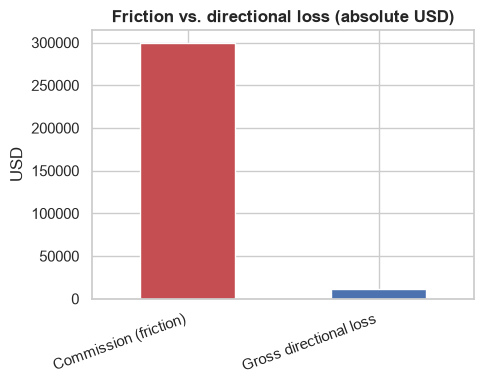

In [52]:
friction = con.execute("SELECT SUM(commission) AS total_commission, SUM(profit) AS total_gross_profit FROM trades_clean").fetchdf().iloc[0]
print(f"Total commission paid:      {friction['total_commission']:,.2f}")
print(f"Total gross (directional) P&L: {friction['total_gross_profit']:,.2f}")

plt.figure(figsize=(5, 4))
pd.Series({"Commission (friction)": abs(friction["total_commission"]), "Gross directional loss": abs(friction["total_gross_profit"])}).plot(
    kind="bar", color=["#C44E52", "#4C72B0"]
)
plt.title("Friction vs. directional loss (absolute USD)")
plt.ylabel("USD")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Total commission paid (−299,239.57) is roughly **25x** the size of the aggregate gross directional loss (−11,833.93). In fact traders' raw market calls were close to breakeven in aggregate — the overwhelming majority of the population's net loss comes from commission, not from picking the wrong direction. This is the strongest single pattern found in this notebook: friction, not trading skill, is the dominant driver of trader loss in this sample.

**Loss-chasing, tested rigorously.** §5.3 compared after-loss vs. after-win sizing at the trade level, but trades within an account aren't independent observations — pooling them into two independent groups understates uncertainty. Here each account contributes one paired observation (its own average size after a loss vs. after a win), and a Wilcoxon signed-rank test is used instead of an independent-groups test.


key finding : trade frequency/overtrading may matter more than trade accuracy.
traders as a group were barely losing money from guessing wrong — almost all of their collective loss came just from the cost of trading itself


In [53]:
#but does this hold for winners too (+ve net profit)

con.execute("""
    SELECT accountId,
           SUM(profit) AS total_directional,
           SUM(commission) AS total_commission
    FROM trades_clean
    GROUP BY accountId
""").fetchdf()

,accountId,total_directional,total_commission
0,D#1702718,-1102.73,-625.98
1,D#1671094,-1972.18,-644.42
2,D#1702495,112.37,-970.36
3,D#1670950,-700.57,-290.68
4,D#1702412,-566.72,-397.50
...,...,...,...
497,D#1702485,-1027.71,-254.26
498,D#1670962,-49.19,-228.66
499,D#1702404,-711.59,-180.90
500,D#1670989,1964.23,-762.18


In [54]:
#does friction/direction ratio hold by campaign or does it vayr

con.execute("""
    SELECT campaignId,
           SUM(profit) AS total_directional,
           SUM(commission) AS total_commission
    FROM trades_clean
    GROUP BY campaignId
""").fetchdf()

,campaignId,total_directional,total_commission
0,34,-5061.16,-3496.76
1,41,848.45,-6600.37
2,38,-741.43,-7411.34
3,40,-5831.01,-6258.94
4,47,-705.51,-6114.52
5,64,-3791.96,-12716.05
6,44,-4606.28,-9698.04
7,46,-1064.57,-8422.54
8,48,4012.01,-9289.77
9,56,7007.17,-11352.37


directional skill/luck varies campaign to campaign — sometimes traders as a group are right, sometimes wrong — but commission is a reliable, unwavering drain in every single one of the 34 campaigns, with no exceptions.

In [55]:
per_account_pressure = (
    pressure_df.groupby(["accountId", "prev_outcome"], observed=True)
    .agg(avg_amount=("amount", "mean"), n=("amount", "size"))
    .unstack("prev_outcome")
)
per_account_pressure.columns = ["_".join(col) for col in per_account_pressure.columns]

eligible = per_account_pressure[(per_account_pressure["n_after_loss"] >= 5) & (per_account_pressure["n_after_win"] >= 5)].dropna()

w_stat, p_value = stats.wilcoxon(eligible["avg_amount_after_loss"], eligible["avg_amount_after_win"])
print(f"Accounts with >=5 after-loss and >=5 after-win trades: {len(eligible)}")
print(f"Median of each account's own avg size after a loss: {eligible['avg_amount_after_loss'].median():.3f}")
print(f"Median of each account's own avg size after a win:  {eligible['avg_amount_after_win'].median():.3f}")
print(f"Wilcoxon signed-rank: stat={w_stat:.1f}, p={p_value:.4f}")

Accounts with >=5 after-loss and >=5 after-win trades: 499
Median of each account's own avg size after a loss: 0.179
Median of each account's own avg size after a win:  0.182
Wilcoxon signed-rank: stat=53490.5, p=0.0058


The paired test is statistically significant (Wilcoxon p = 0.0058, n = 499 accounts) — but in the **opposite direction** to the loss-chasing hypothesis. Median size after a loss (0.179 lots) is very slightly *smaller* than after a win (0.182 lots). The difference reaches significance only because of the large paired sample; the effect size (≈0.003 lots, ~1.6%) is economically negligible. **Conclusion: this dataset does not support "traders size up after a loss."** If anything there's a marginal, practically unimportant tendency to size down — consistent with the after-loss trade-level finding in §5.3, and worth stating plainly in §7 rather than forcing the hypothesis to fit.

**Round-number price anchoring.** Do entries cluster near round $10 gold levels rather than falling anywhere? Measured as each trade's distance from the nearest multiple of 10 in `openPrice`; under no anchoring this distance would be roughly uniform on [0, 5] with a mean of 2.5.


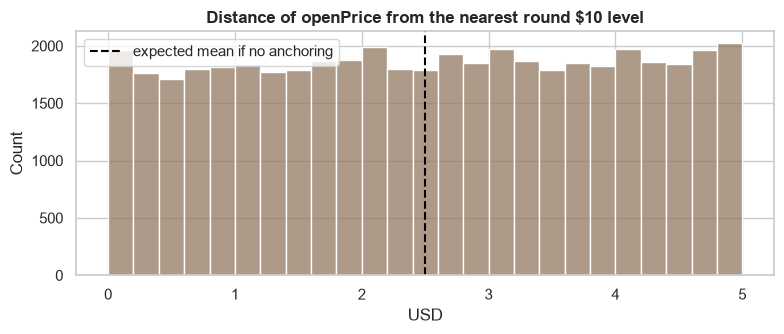

Observed mean distance: 2.53  (2.50 expected under no anchoring)


In [56]:
remainder = trades_clean["openPrice"] % 10
dist_to_round10 = pd.concat([remainder, 10 - remainder], axis=1).min(axis=1)

plt.figure(figsize=(8, 3.5))
sns.histplot(dist_to_round10, bins=25, color="#937860")
plt.axvline(2.5, color="black", linestyle="--", label="expected mean if no anchoring")
plt.title("Distance of openPrice from the nearest round $10 level")
plt.xlabel("USD")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Observed mean distance: {dist_to_round10.mean():.2f}  (2.50 expected under no anchoring)")

No evidence of round-number anchoring: the observed mean distance from the nearest $10 level is 2.53, essentially identical to the 2.50 expected if entry prices were uniformly distributed. The histogram is flat rather than peaked near zero. **This pattern is not supported by the data** — worth noting as a negative result rather than omitting it, since it rules out one plausible behavioural story.

**Stability across campaigns.** With 34 campaigns available — far more than a single-campaign sample would give — it's worth checking whether the no-SL rate and average profit are a stable pattern over time, or an artifact of one unusual campaign.


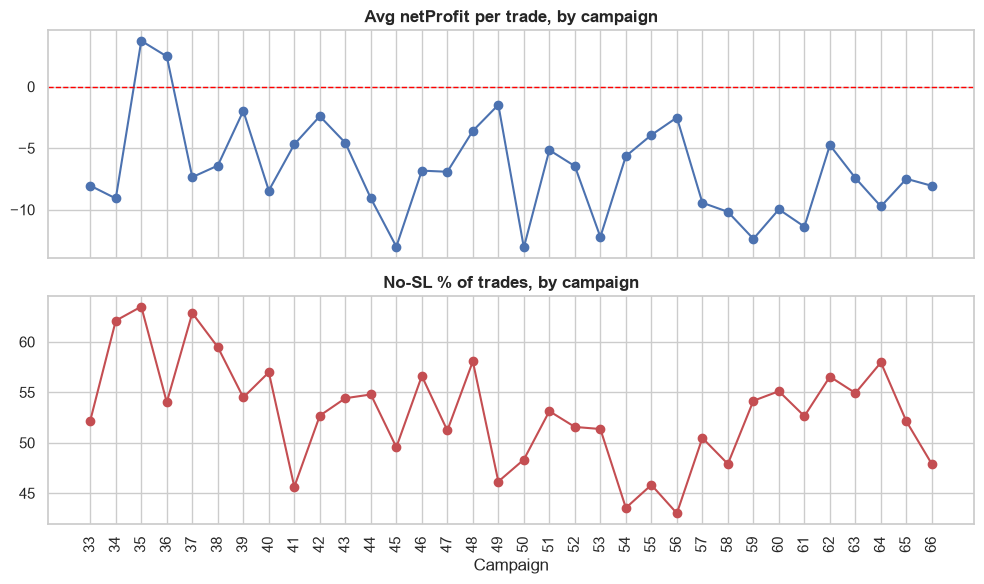

In [57]:
campaign_trend = con.execute("""
    SELECT
        campaignId,
        AVG(netProfit) AS avg_profit,
        100.0 * SUM(CASE WHEN NOT has_SL THEN 1 ELSE 0 END) / COUNT(*) AS no_sl_pct
    FROM trades_clean
    GROUP BY campaignId
    ORDER BY campaignId
""").fetchdf()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(campaign_trend["campaignId"], campaign_trend["avg_profit"], marker="o", color="#4C72B0")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Avg netProfit per trade, by campaign")

axes[1].plot(campaign_trend["campaignId"], campaign_trend["no_sl_pct"], marker="o", color="#C44E52")
axes[1].set_title("No-SL % of trades, by campaign")
axes[1].set_xlabel("Campaign")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Both patterns hold up as stable, not campaign-specific artifacts. Average netProfit per trade is negative in 32 of the 34 campaigns (range −13.07 to +3.73), and the no-SL rate stays in a fairly tight band across all 34 campaigns (43.0%–63.5%, std ≈ 5.2 points) — never dropping anywhere close to a genuinely disciplined norm. Nothing here looks driven by one unusual campaign; the friction and stop-loss findings above should generalize across the programme, not just this sample.

> **Takeaway:** §5.5 closes the EDA with the patterns most likely to survive contact with Stage 2 — friction (strong, 25x), loss-chasing (tested rigorously and **not** supported — sizing is flat to marginally smaller after a loss), and round-number anchoring (tested and **not** supported) — plus a check that the friction/no-SL patterns are stable across all 34 campaigns, not an artifact of one. §6 consolidates everything from §5 into one reviewable list.


In [58]:
#more campaign lvel trend 
campaign_level = con.execute("""
    SELECT campaignId,
           AVG(netProfit) AS avg_netprofit,
           100.0 * SUM(CASE WHEN NOT has_SL THEN 1 ELSE 0 END) / COUNT(*) AS no_sl_pct
    FROM trades_clean
    GROUP BY campaignId
""").fetchdf()

campaign_level[["avg_netprofit", "no_sl_pct"]].corr()

,avg_netprofit,no_sl_pct
avg_netprofit,1.000000,0.080899
no_sl_pct,0.080899,1.000000


## 6 · Key Observations

1. **Commission dwarfs directional loss.** Total commission paid (−299,239.57) is ≈25x the aggregate gross directional P&L (−11,833.93); traders were close to breakeven on raw market calls in aggregate. *Robust* — holds across all 34 campaigns (§5.5).
2. **Over half of trades carry no stop-loss.** 52.9% of trades have no `slPrice` set, 45.0% have no `tpPrice`; the rate is stable across campaigns (43.0–63.5%) and no account sits at either 0% or 100%. *Robust* (§3.2, §5.2).
3. **No-SL risk is asymmetric, not simply worse.** No-SL trades have a worse mean (−10.01 vs. −2.96) and worse tail (−944.10 vs. −577.80) than has-SL trades, but a *better* median (+1.98 vs. −10.56) — small frequent edge, occasional blow-up. *Robust* given n = 46,520, but the net effect on account outcome is not significant (§5.4).
4. Of eleven behavioral metrics tested against outcome, only maximum drawdown from an account's own peak showed a strong, significant separation (p < 0.001, losers −1515 vs winners −839); the rest — trade count, lot size, duration, no-SL rate, commission — were statistically indistinguishable.
5. **Loss-chasing by size is not supported — if anything sizing shrinks.** A paired per-account test (n = 499) found post-loss sizing very slightly *smaller* than post-win (0.179 vs. 0.182 lots, p = 0.0058); lot size also shrinks steadily the longer a session runs (0.196 → 0.12 across session hours). *Robust*, but the effect is in the opposite direction to the original hypothesis (§5.3, §5.5).
6. **Trading activity is heavily front-loaded.** ≈70% of trades happen in the first 4 hours of a session, and median re-entry gap between trades is just 4.4 minutes. *Robust* (§5.2, §5.3).
7. **Round-number price anchoring is not supported.** Observed mean distance from the nearest $10 gold level (2.53) matches the 2.50 expected under no anchoring. *Robust* null result (§5.5).
8. **Registry data quality is worse than it first appears.** The `users` table has exactly 14 rows per account (a data-generation artifact, not real re-registrations) and none of `positionId`/`closeTradeId`/`openOrderId` is a genuine per-trade key. Both were caught in §3.1 and handled in §4 rather than silently trusted. *Robust*, and a caveat on everything IP-related.
9. **Shared-IP multi-accounting is a large but low-confidence signal.** 37.6% of traded accounts sit on a hashed IP shared with another account (largest cluster: 9 accounts) — notable in scale, but the underlying IP was picked arbitrarily from each account's 14 registry rows (#8), so treat as *preliminary* and worth a cleaner data pull before acting on it (§5.1).
10. **Direction is close to balanced.** 50.5% BUY vs. 49.5% SELL across the full 34-campaign sample — a much smaller long bias than a single-campaign sample would suggest. *Robust* (§5.2).
11. Winners re-enter slightly slower after a win than losers do (6.47 vs 5.38 min, p=0.029)
12. userGroupId is unusable for cohort comparison


in all, **trading frequency and cost management (commission drag, drawdown depth) matter more than directional skill or simple rule-following (SL usage, sizing, timing) in separating outcomes.**

## 7 · Hypothesis Generation

Five falsifiable claims, each grounded in a specific §5 finding, with the metric and confirm/reject rule that would test it further. With 502 accounts across one campaign family, treat every result as indicative, not conclusive. Two of the five are **not** supported by this stage's evidence — reported as such rather than dropped, since a rejected hypothesis is still a useful Stage 1 result.

| # | Observation | Hypothesis | How it will be tested | Status |
|---|---|---|---|---|
| 1 | Median holding time is nearly identical for winners (295s) and losers (281s), p = 0.56 (§5.4 Mann-Whitney) | Traders who hold losing trades longer than winning trades finish with lower net P&L (disposition effect) | Per-account: correlate (loser-hold − winner-hold) against total net P&L; confirm if consistently negative | **Not supported at the account level this stage** — the simple duration-by-outcome cut shows no difference. A within-account loser-hold vs. winner-hold correlation (a finer-grained cut) is a Stage 2 follow-up before fully rejecting |
| 2 | Total commission (−299,239.57) is ≈25x the aggregate gross directional loss (−11,833.93); pattern holds across all 34 campaigns (§5.5) | A meaningful share of trader losses is explained by commission/churn rather than directional error | Compare total commission to total gross directional loss; confirm if friction is a large share of the loss | **Strongly supported** — the clearest finding in this notebook |
| 3 | No-SL trades have a worse average (−10.01 vs. −2.96) and worse worst-case (−944.10 vs. −577.80) than has-SL trades, but a *better* median (+1.98 vs. −10.56); account-level 50%-threshold split not significant (p = 0.47) (§5.4) | Trades placed without a stop-loss have worse downside than trades with one | Compare has_SL vs. no-SL trade-level and account-level outcomes (Mann-Whitney / Welch t-test); confirm if no-SL fares worse | **Partially supported** — worse in the tail, not in the typical case; nuance matters more than a yes/no verdict |
| 4 | Paired per-account test (n = 499) is significant (p = 0.0058) but in the *opposite* direction: median size after a loss (0.179) is marginally smaller than after a win (0.182) (§5.5) | Traders increase position size more after a loss than after a win | Per-account paired comparison of avg size after-loss vs. after-win (Wilcoxon signed-rank); confirm if after-loss is consistently larger | **Not supported** — statistically significant but in the wrong direction, and the effect size (~1.6%) is economically negligible |
| 5 | 189 of 502 traded accounts (37.6%) sit on a hashed IP shared by ≥1 other account; largest cluster is 9 accounts (§5.1) | Accounts sharing a hashed IP behave more similarly to each other than to independent accounts | Compare within-IP-cluster vs. across-cluster variance in key behaviours (no_sl_pct, avg_amount); confirm if within-cluster variance is markedly lower | **Not tested this stage** — the descriptive rate alone is notable, but formal testing needs a variance-decomposition approach beyond simple EDA, and the underlying IP field has the §4 caveat about arbitrary selection among 14 registry rows |


## 8 · Summary & Next Steps

### 8.1 Most promising hypotheses

Ranked by strength of Stage-1 evidence, robustness across accounts/campaigns, and alignment with C22's exploit-the-mistake goal. Two of the five hypotheses tested (#1 disposition, #4 loss-chasing) were **not** supported and are intentionally left out of this ranking rather than forced in.

1. **Friction / commission bleed (#2).** Commission is ≈25x the aggregate directional loss and the pattern is stable across all 34 campaigns — the strongest, most robust, most directly exploitable finding in this notebook.
2. **No-SL risk asymmetry (#3).** Not a simple "worse," but a real and robust tail-risk pattern (worse mean and worst-case, better median) — the kind of risk-discipline gap a challenge programme is specifically designed to detect.
3. **Shared-IP / multi-accounting (#5).** Untested statistically this stage, but 37.6% of traded accounts sharing an IP is too large a descriptive signal to ignore — the top candidate for a focused Stage 2 pull once cleaner registry data (one row per account) is available.


In [59]:
print("=== EDA SUMMARY ===")
print(f"Total trades:            {len(trades_clean):,}")
print(f"Total accounts:          {trades_clean['accountId'].nunique()}")
print(f"Campaigns covered:       {trades_clean['campaignId'].nunique()}")
print(f"Overall avg netProfit:   {trades_clean['netProfit'].mean():.2f}")
print(f"% trades with no SL:     {(1 - trades_clean['has_SL'].mean()) * 100:.1f}%")
print(f"% trades with no TP:     {(1 - trades_clean['has_TP'].mean()) * 100:.1f}%")
print(f"Trade direction (BUY):   {(trades_clean['side'] == 'BUY').mean() * 100:.1f}%")
print(f"Winner / loser accounts: {(account_summary['outcome'] == 'winner').sum()} / {(account_summary['outcome'] == 'loser').sum()}")
print(f"Accounts on a shared IP: {n_traded_flagged} of {len(traded_flags)}")

=== EDA SUMMARY ===
Total trades:            46,520
Total accounts:          502
Campaigns covered:       34
Overall avg netProfit:   -6.69
% trades with no SL:     52.9%
% trades with no TP:     45.0%
Trade direction (BUY):   50.5%
Winner / loser accounts: 134 / 368
Accounts on a shared IP: 189 of 502


### 8.2 Proposed analyses for Stage 2 (signpost only — no features or models here)

- The disposition and loss-chasing signals warrant a formal behavioural-sequence analysis (per-account, time-ordered), building on `trades_sorted` from §5.2/§5.3
- The shared-IP hypothesis (§7, #5) needs a variance-decomposition or clustering approach beyond this notebook's scope
- Anti-martingale / grid re-entry (§1.2) were mapped to data proxies but not tested — worth a dedicated pass once priorities are set

**Data to request from C22 before hypotheses harden:**
- Starting account balance, to express the 4% / 8% rules as percentages rather than absolute USD
- Breach / pass-fail outcome labels — absent from this extract, and the only way to move from the `netProfit`-sign proxy to the true challenge outcome
- Clarification of what `userGroupId` encodes
- Whether more campaigns exist beyond 33–66, and whether campaigns before 33 were intentionally excluded

In [62]:
import duckdb
import pandas as pd
from scipy import stats

# ---------------------------------------------------------
# Step 0: Connect and load everything needed
# ---------------------------------------------------------
con = duckdb.connect("../Data/processed/project.duckdb")

trades_clean_df = con.execute("SELECT * FROM trades_clean").fetchdf()

account_summary = con.execute("""
    SELECT accountId,
           COUNT(*) AS n_trades,
           SUM(netProfit) AS total_netProfit
    FROM trades_clean
    GROUP BY accountId
""").fetchdf()
account_summary["outcome"] = account_summary["total_netProfit"].apply(lambda x: "winner" if x > 0 else "loser")

trades_with_trader_df = con.execute("SELECT * FROM trades_with_trader WHERE traderId IS NOT NULL").fetchdf()
rebuilt_account_summary = pd.read_csv("../Data/processed/rebuilt_account_summary.csv")

print("Loaded OLD account_summary:", account_summary.shape)
print("Loaded NEW rebuilt_account_summary:", rebuilt_account_summary.shape)

# ---------------------------------------------------------
# Part 1: Max drawdown — FAST vectorized version
# ---------------------------------------------------------
def fast_max_drawdown(df, id_col):
    df = df.sort_values([id_col, "openDateTime"]).copy()
    df["equity"] = df.groupby(id_col)["netProfit"].cumsum()
    df["running_max"] = df.groupby(id_col)["equity"].cummax()
    df["drawdown"] = df["equity"] - df["running_max"]
    return df.groupby(id_col)["drawdown"].min().reset_index(name="max_drawdown")

old_dd = fast_max_drawdown(trades_clean_df, "accountId")
account_summary = account_summary.merge(old_dd, on="accountId", how="left")

new_dd = fast_max_drawdown(trades_with_trader_df, "traderId")
rebuilt_account_summary = rebuilt_account_summary.merge(new_dd, on="traderId", how="left")

old_winners = account_summary[account_summary["outcome"] == "winner"]
old_losers = account_summary[account_summary["outcome"] == "loser"]
old_u, old_p = stats.mannwhitneyu(old_winners["max_drawdown"].dropna(), old_losers["max_drawdown"].dropna())

new_winners = rebuilt_account_summary[rebuilt_account_summary["outcome"] == "winner"]
new_losers = rebuilt_account_summary[rebuilt_account_summary["outcome"] == "loser"]
new_u, new_p = stats.mannwhitneyu(new_winners["max_drawdown"].dropna(), new_losers["max_drawdown"].dropna())

print("\n=== MAX DRAWDOWN: winner vs loser ===")
print(f"{'':20} {'OLD (accountId)':>20} {'NEW (traderId)':>20}")
print(f"{'Winner median':20} {old_winners['max_drawdown'].median():>20.1f} {new_winners['max_drawdown'].median():>20.1f}")
print(f"{'Loser median':20} {old_losers['max_drawdown'].median():>20.1f} {new_losers['max_drawdown'].median():>20.1f}")
print(f"{'p-value':20} {old_p:>20.6f} {new_p:>20.6f}")

# ---------------------------------------------------------
# Part 2: No-SL asymmetry (trade level)
# ---------------------------------------------------------
old_slcut = con.execute("""
    SELECT has_SL, AVG(netProfit) AS avg_profit, MEDIAN(netProfit) AS median_profit, MIN(netProfit) AS worst_loss
    FROM trades_clean GROUP BY has_SL
""").fetchdf()

new_slcut = con.execute("""
    SELECT has_SL, AVG(netProfit) AS avg_profit, MEDIAN(netProfit) AS median_profit, MIN(netProfit) AS worst_loss
    FROM trades_with_trader GROUP BY has_SL
""").fetchdf()

print("\n=== NO-SL vs HAS-SL (trade level) ===")
print("OLD:\n", old_slcut)
print("NEW:\n", new_slcut)

# ---------------------------------------------------------
# Part 3: Winner/loser counts
# ---------------------------------------------------------
print("\n=== WINNER/LOSER COUNTS ===")
print("OLD:", account_summary["outcome"].value_counts().to_dict(), f"(n={len(account_summary)})")
print("NEW:", rebuilt_account_summary["outcome"].value_counts().to_dict(), f"(n={len(rebuilt_account_summary)})")

Loaded OLD account_summary: (502, 4)
Loaded NEW rebuilt_account_summary: (3550, 11)

=== MAX DRAWDOWN: winner vs loser ===
                          OLD (accountId)       NEW (traderId)
Winner median                      -839.3                -30.0
Loser median                      -1515.0               -230.9
p-value                          0.000000             0.000000

=== NO-SL vs HAS-SL (trade level) ===
OLD:
    has_SL  avg_profit  median_profit  worst_loss
0    True   -2.958618         -10.56      -577.8
1   False  -10.008681           1.98      -944.1
NEW:
    has_SL  avg_profit  median_profit  worst_loss
0   False  -10.008681           1.98      -944.1
1    True   -2.958618         -10.56      -577.8

=== WINNER/LOSER COUNTS ===
OLD: {'loser': 368, 'winner': 134} (n=502)
NEW: {'loser': 2211, 'winner': 1339} (n=3550)


In [63]:
# OLD
old_hold = con.execute("""
    SELECT accountId, MEDIAN(durationSec) AS median_hold
    FROM trades_clean_df GROUP BY accountId
""").fetchdf() if False else trades_clean_df.groupby("accountId")["durationSec"].median().reset_index(name="median_hold")
account_summary = account_summary.merge(old_hold, on="accountId", how="left")

old_w = account_summary[account_summary["outcome"]=="winner"]["median_hold"].dropna()
old_l = account_summary[account_summary["outcome"]=="loser"]["median_hold"].dropna()
old_u1, old_p1 = stats.mannwhitneyu(old_w, old_l)

# NEW
new_hold = trades_with_trader_df.groupby("traderId")["durationSec"].median().reset_index(name="median_hold")
rebuilt_account_summary = rebuilt_account_summary.merge(new_hold, on="traderId", how="left")

new_w = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="winner"]["median_hold"].dropna()
new_l = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="loser"]["median_hold"].dropna()
new_u1, new_p1 = stats.mannwhitneyu(new_w, new_l)

print("=== HOLDING TIME: winner vs loser ===")
print(f"OLD — winner: {old_w.median():.1f}, loser: {old_l.median():.1f}, p={old_p1:.4f}")
print(f"NEW — winner: {new_w.median():.1f}, loser: {new_l.median():.1f}, p={new_p1:.4f}")

=== HOLDING TIME: winner vs loser ===
OLD — winner: 295.2, loser: 281.0, p=0.5590
NEW — winner: 610.0, loser: 480.0, p=0.0009


In [64]:
old_comm = con.execute("SELECT SUM(commission) AS c, SUM(profit) AS d FROM trades_clean_df").fetchdf() if False else None
old_c = trades_clean_df["commission"].sum()
old_d = trades_clean_df["profit"].sum()
new_c = trades_with_trader_df["commission"].sum()
new_d = trades_with_trader_df["profit"].sum()

print("\n=== COMMISSION vs DIRECTIONAL LOSS ===")
print(f"OLD — commission: {old_c:.2f}, directional: {old_d:.2f}, ratio: {abs(old_c/old_d):.1f}x")
print(f"NEW — commission: {new_c:.2f}, directional: {new_d:.2f}, ratio: {abs(new_c/new_d):.1f}x")


=== COMMISSION vs DIRECTIONAL LOSS ===
OLD — commission: -299239.57, directional: -11833.93, ratio: 25.3x
NEW — commission: -298472.87, directional: -10487.16, ratio: 28.5x


In [65]:
# OLD
account_summary["no_sl_pct"] = trades_clean_df.groupby("accountId")["has_SL"].apply(lambda x: 100*(~x).mean()).values
old_high = account_summary[account_summary["no_sl_pct"] >= 50]["total_netProfit"]
old_low = account_summary[account_summary["no_sl_pct"] < 50]["total_netProfit"]
old_t3, old_p3 = stats.ttest_ind(old_high, old_low, equal_var=False)

# NEW
new_high = rebuilt_account_summary[rebuilt_account_summary["no_sl_pct"] >= 50]["total_netProfit"]
new_low = rebuilt_account_summary[rebuilt_account_summary["no_sl_pct"] < 50]["total_netProfit"]
new_t3, new_p3 = stats.ttest_ind(new_high, new_low, equal_var=False)

print("\n=== HIGH vs LOW NO-SL % (account level, 50% threshold) ===")
print(f"OLD — high no-SL avg profit: {old_high.mean():.2f}, low: {old_low.mean():.2f}, p={old_p3:.4f}")
print(f"NEW — high no-SL avg profit: {new_high.mean():.2f}, low: {new_low.mean():.2f}, p={new_p3:.4f}")


=== HIGH vs LOW NO-SL % (account level, 50% threshold) ===
OLD — high no-SL avg profit: -642.75, low: -588.34, p=0.5365
NEW — high no-SL avg profit: -94.78, low: -75.95, p=0.1716


In [66]:
def get_after_loss_win_sizes(df, id_col):
    df = df.sort_values([id_col, "openDateTime"]).copy()
    df["prev_netProfit"] = df.groupby(id_col)["netProfit"].shift(1)
    df["prev_outcome"] = df["prev_netProfit"].apply(lambda x: "after_loss" if x < 0 else ("after_win" if x >= 0 else None))
    sizes = df.groupby([id_col, "prev_outcome"])["amount"].mean().unstack()
    sizes.columns = ["after_loss", "after_win"]
    return sizes.dropna()

old_sizes = get_after_loss_win_sizes(trades_clean_df, "accountId")
old_w4, old_p4 = stats.wilcoxon(old_sizes["after_loss"], old_sizes["after_win"])

new_sizes = get_after_loss_win_sizes(trades_with_trader_df, "traderId")
new_w4, new_p4 = stats.wilcoxon(new_sizes["after_loss"], new_sizes["after_win"])

print("\n=== SIZE AFTER LOSS vs AFTER WIN ===")
print(f"OLD — after_loss: {old_sizes['after_loss'].median():.3f}, after_win: {old_sizes['after_win'].median():.3f}, p={old_p4:.4f} (n={len(old_sizes)})")
print(f"NEW — after_loss: {new_sizes['after_loss'].median():.3f}, after_win: {new_sizes['after_win'].median():.3f}, p={new_p4:.4f} (n={len(new_sizes)})")


=== SIZE AFTER LOSS vs AFTER WIN ===
OLD — after_loss: 0.179, after_win: 0.182, p=0.0047 (n=500)
NEW — after_loss: 0.159, after_win: 0.150, p=0.0033 (n=2043)


over here the output flipped, so this hypothesis - Paired per-account test (n = 499) is significant (p = 0.0058) but in the *opposite* direction: median size after a loss (0.179) is marginally smaller than after a win (0.182) (§5.5) is inconclusive for us